---
title: "EPS: prevalence and persistence of alcohol use"
subtitle: "Survey-wave audit, extension to ages 66–70 and 71–76, and longitudinal estimation"
author: "FONDECYT 1240138"
date: "2026-09-21"
lang: en
format:
  html:
    theme: journal
    toc: true
    toc-location: left
    code-fold: true
    code-summary: "Show R code"
    embed-resources: true
execute:
  echo: true
  warning: true
  error: false
---


<style>
table {font-size: .88rem;} th {text-align: left;}
.eps-table {overflow-x: auto; margin-bottom: 1.2rem;}
</style>

## 1. Read first: what this notebook answers

**Objective:** estimate alcohol-use prevalence by age, sex and education from the local **Encuesta de Protección Social (EPS; Social Protection Survey)** files, and measure persistence among linked respondents. The analysis preserves the existing `expand_pif*` notebooks, microsimulation engine and RR/AAF/PIF calculations.

1. Audit survey waves and variables before harmonizing them.
2. Estimate reported use and operational drinking categories, with missingness and assumptions visible.
3. Keep true lifetime abstinence distinct from observed history. **Section 6.1 estimates the authorized Calvo-style lifetime-abstainer proxy using repeated non-use over at least four years**; the earlier `NA` table remains a reference on exact identification.
4. Estimate transitions and latent rho between interviews, with annualization under an explicit assumption.

The order follows the precedent: setup → inputs → derivations → survey design → estimates → validation → exports → session information and references. All R analysis is contained here; no external analytical scripts are executed. Full tables are exported, with summaries displayed in the notebook.

**Hypothesis before estimation:** reported use will be more persistent than under independence between interviews. This is assessed against rho = 0, without fixing rho at 0.8 or choosing it to reproduce cross-sectional prevalence. The association may reflect stable differences between people and survivor selection as well as temporal dependence.

**Completion criteria:** one-to-one links, valid weights, audited missingness, explicit intervals and denominators, categories summing to one within the relevant analysis, recovery of a known synthetic rho, and complete execution on real data.


In [1]:
#| label: eps-setup
.t0 <- Sys.time()
# Project-relative paths; microdata come only from the encrypted bundles through _tools/acc_data.R.
eps_required <- c("here", "haven", "survey", "mvtnorm", "ggplot2", "knitr", "htmltools")
eps_missing <- eps_required[!vapply(eps_required, requireNamespace, logical(1), quietly = TRUE)]
if (length(eps_missing)) stop("Install the missing packages before running: ", paste(eps_missing, collapse = ", "))
suppressMessages(here::i_am("__andres_control/eps_alcohol_prevalencia_persistencia.ipynb"))
source(here::here("_tools", "acc_data.R"))
eps_root <- acc_data("_eps/eps.tar.xz.enc")   # decrypted once per session into tempdir()
eps_abs <- function(x) file.path(eps_root, sub("^_eps/", "", x))   # "_eps/<path>" label -> readable file
eps_out <- here::here("__andres_control", "eps_alcohol_outputs")
dir.create(eps_out, recursive = TRUE, showWarnings = FALSE)
options(survey.lonely.psu = "adjust", survey.adjust.domain.lonely = TRUE, scipen = 8)
# Use the system's native character locale; this also avoids C-locale glyph escapes on Windows.
invisible(Sys.setlocale("LC_CTYPE", ""))
eps_seed <- 1240138L
set.seed(eps_seed)
eps_age_levels <- c("18-29", "30-44", "45-59", "60-65", "66-70", "71-76", "77+")
eps_edu_levels <- c("Primary completed or less", "Secondary completed or less", "Tertiary completed or higher")
eps_states <- c("Current abstainer (history unknown)", "Occasional (frequency proxy)", "Moderate", "Heavy")
eps_table <- function(x, caption, digits = 3) {
  htmltools::browsable(htmltools::div(class = "eps-table",
    htmltools::HTML(knitr::kable(x, format = "html", digits = digits, caption = caption, row.names = FALSE))))
}
eps_read <- function(path) {
  x <- as.data.frame(haven::read_dta(eps_abs(path)))
  stopifnot("folio_n20" %in% names(x), !anyNA(x$folio_n20), !anyDuplicated(x$folio_n20))
  x
}
eps_save <- function(x, name) utils::write.csv(x, file.path(eps_out, paste0(name, ".csv")), row.names = FALSE, na = "")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

Elapsed: 0.01 minutes


### Analysis map

Follow the three paths below. **EPS supports the older age extension and longitudinal history. ENPG supplies directly asked heavy episodic drinking (HED) within its sampled ages.** The different outcomes and populations remain explicit in every export. Original variable labels and source filenames stay in Spanish so they can be checked against the questionnaires.

Elapsed: 0.01 minutes


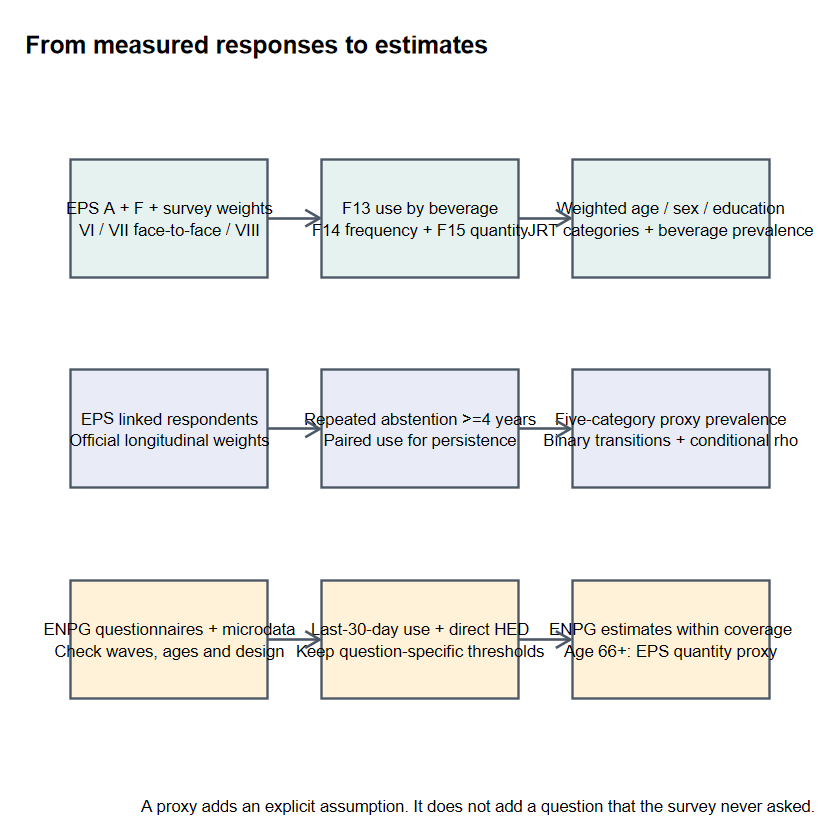

In [2]:
#| label: eps-concept-map
.t0 <- Sys.time()
# A static, exportable concept map uses the plotting package already needed below.
map_nodes <- data.frame(
  x = rep(c(1, 4, 7), 3), y = rep(c(3, 2, 1), each = 3),
  text = c("EPS A + F + survey weights\nVI / VII face-to-face / VIII",
           "F13 use by beverage\nF14 frequency + F15 quantity",
           "Weighted age / sex / education\nJRT categories + beverage prevalence",
           "EPS linked respondents\nOfficial longitudinal weights",
           "Repeated abstention >=4 years\nPaired use for persistence",
           "Five-category proxy prevalence\nBinary transitions + conditional rho",
           "ENPG questionnaires + microdata\nCheck waves, ages and design",
           "Last-30-day use + direct HED\nKeep question-specific thresholds",
           "ENPG estimates within coverage\nAge 66+: EPS quantity proxy"))
map_edges <- data.frame(x = rep(c(2.18, 5.18), 3), xend = rep(c(2.80, 5.80), 3),
                        y = rep(c(3, 2, 1), each = 2))
eps_map <- ggplot2::ggplot() +
  ggplot2::geom_rect(data = map_nodes, ggplot2::aes(xmin = x - 1.18, xmax = x + 1.18, ymin = y - .28, ymax = y + .28),
    fill = rep(c("#e6f2f0", "#e9ecf7", "#fff2d9"), each = 3), colour = "#4c5866", linewidth = .5) +
  ggplot2::geom_text(data = map_nodes, ggplot2::aes(x, y, label = text), size = 3.4, lineheight = 1.12) +
  ggplot2::geom_segment(data = map_edges, ggplot2::aes(x = x, xend = xend, y = y, yend = y),
    arrow = grid::arrow(length = grid::unit(.14, "inches")), colour = "#4c5866") +
  ggplot2::coord_cartesian(xlim = c(-.3, 8.3), ylim = c(.45, 3.6), clip = "off") +
  ggplot2::theme_void(base_size = 12) + ggplot2::labs(title = "From measured responses to estimates",
    caption = "A proxy adds an explicit assumption. It does not add a question that the survey never asked.") +
  ggplot2::theme(plot.background = ggplot2::element_rect(fill = "white", colour = NA), plot.title = ggplot2::element_text(face = "bold"), plot.margin = ggplot2::margin(15, 15, 15, 15))
print(eps_map)
ggplot2::ggsave(file.path(eps_out, "analysis_concept_map.png"), eps_map, width = 13, height = 5.8, dpi = 180, bg = "white")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

## 2. Survey waves, data files and comparability limits

| Wave and files | Use in this analysis | Verified limitation |
|---|---|---|
| V / 2012: `entrevistado`, `salud`, corrected/original/panel weights | Inventory and audit | The local files do not contain F13–F15. The official dossier concludes that this wave should not support statistical inference (p. 23). Alcohol is not imputed, and no 2012 alcohol prevalence is estimated. |
| VI / EPS 2015, fieldwork March–August 2016: modules A/F and weights | Baseline prevalence and linkage | Cross-sectional weights are available; PSU and stratum identifiers were not found in the local public files for this wave. Approximate confidence intervals use weights only. |
| VII / EPS 2020 in-person interviews, fieldwork 14 December 2019–22 March 2020 | Prevalence and secondary transition analysis | F13–F15 have a comparable structure. The follow-up sample has no refreshment, and weights are calibrated to ages 23+, although some respondents are 22. The identifier `VII_presencial` denotes this component, rather than a uniform measurement covering all of 2020 or everyone aged 18+. |
| VII telephone continuity and re-interview components | Separate audit | `fc101_1` asks whether respondents consume less, the same or more than usual. It does not measure absolute drinking status or volume. “The same” may include non-drinkers, and “not applicable” is not recoded as abstinence. Re-interviews overlap with the in-person component. |
| VIII / EPS 2023, fieldwork 11 October 2023–10 June 2024: modules A/F and XS/panel weights | Most recent prevalence and primary VI→VIII transition | Sample refreshment and changes to non-response and education codes. The 2015 panel weight requires participation in VI, VII and VIII and includes both VII in-person and continuity respondents. It does not cover every respondent linked at the two endpoints. |

Questionnaires for deceased respondents and respondents unable to answer/PSD use proxy informants and different populations. They are counted in the inventory but are not combined with self-reports from living respondents. Death, disability and non-response are not abstinence.

**Survey design:** VII/VIII weights include `strata_ID` and `cluster_ID`. Some strata contain a single primary sampling unit (PSU). The analysis uses `survey.lonely.psu="adjust"` and compares it with `certainty`, the convention in the official example syntax, without claiming that every singleton PSU was sampled with certainty.


In [3]:
#| label: eps-inventory
.t0 <- Sys.time()
eps_files <- list.files(eps_root, pattern = "\\.dta$", recursive = TRUE, full.names = TRUE)
eps_relative <- function(x) paste0("_eps/", substring(gsub("\\\\", "/", x), nchar(gsub("\\\\", "/", eps_root)) + 2L))
eps_inventory <- do.call(rbind, lapply(eps_files, function(p) {
  h <- haven::read_dta(p, n_max = 0)
  data.frame(file = eps_relative(p), variables = ncol(h), bytes = file.info(p)$size,
    has_f13 = all(paste0("f13_", 1:3) %in% names(h)),
    has_f14 = all(paste0("f14_", 1:3) %in% names(h)),
    has_f15 = all(paste0("f15_", 1:3) %in% names(h)), has_relative_change = "fc101_1" %in% names(h),
    has_psu = "cluster_ID" %in% names(h), has_strata = "strata_ID" %in% names(h))
}))
stopifnot(!any(eps_inventory$has_f13[grepl("_eps/2012/", eps_inventory$file)]))
eps_save(eps_inventory, "file_inventory")
eps_table(eps_inventory[eps_inventory$has_f13 | eps_inventory$has_relative_change, c("file", "variables", "has_f14", "has_f15", "has_relative_change")],
          "Files with absolute use or relative change; full inventory in CSV")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

file,variables,has_f14,has_f15,has_relative_change
_eps/2015/2015/MODULOF_entrevistado.dta,203,TRUE,TRUE,FALSE
_eps/Bases de datos EPS VIII Ronda/BBDD_VIVOS/MODULO_F_ENTREVISTADO.dta,240,TRUE,TRUE,FALSE
_eps/Bases y Documentos EPS 2020/2020/Bases_EPS2020_continuidad/01_Vivos_continuidad/MODULO_Entrevistado_VIVOS_in.dta,149,FALSE,FALSE,TRUE
_eps/Bases y Documentos EPS 2020/2020/Bases_EPS2020_presencial/01_Vivos presencial/MODULO_F_Entrevistado_in.dta,244,TRUE,TRUE,FALSE
_eps/Bases y Documentos EPS 2020/2020/Bases_EPS2020_reentrevista/01_Vivos reentrevista/MODULO_Entrevistado_VIVOS_in.dta,100,FALSE,FALSE,TRUE


Elapsed: 0.01 minutes


In [4]:
#| label: eps-inputs
.t0 <- Sys.time()
eps_vii <- "_eps/Bases y Documentos EPS 2020"
eps_viii <- "_eps/Bases de datos EPS VIII Ronda"
eps_paths <- list(
  VI = c(a = "_eps/2015/2015/MODULOA_entrevistado.dta", f = "_eps/2015/2015/MODULOF_entrevistado.dta",
         w = "_eps/2015/2015/FactoresExpansionVIRondaEPS.dta"),
  VII_presencial = c(a = paste0(eps_vii, "/2020/Bases_EPS2020_presencial/01_Vivos presencial/MODULO_A_Entrevistado_in.dta"),
                    f = paste0(eps_vii, "/2020/Bases_EPS2020_presencial/01_Vivos presencial/MODULO_F_Entrevistado_in.dta"),
                    w = paste0(eps_vii, "/Factores de Expansion EPS 2020/Factor_XS_EPS_PRES_in.dta")),
  VIII = c(a = paste0(eps_viii, "/BBDD_VIVOS/MODULO_A_ENTREVISTADO.dta"),
           f = paste0(eps_viii, "/BBDD_VIVOS/MODULO_F_ENTREVISTADO.dta"),
           w = paste0(eps_viii, "/FACT_EXP/Factor_XS_EPS_2023.dta")))
eps_raw <- lapply(eps_paths, function(z) lapply(z, eps_read))
eps_panel_paths <- c(VI_VII = paste0(eps_vii, "/Factores de Expansion EPS 2020/Factor_Panel_EPS_PRES_2015_in.dta"),
                    VI_VIII = paste0(eps_viii, "/FACT_EXP/Factor_Panel_EPS_2023_2015.dta"))
eps_panel_weights <- lapply(eps_panel_paths, eps_read)
eps_phone_paths <- c(continuidad = paste0(eps_vii, "/2020/Bases_EPS2020_continuidad/01_Vivos_continuidad/MODULO_Entrevistado_VIVOS_in.dta"),
                     reentrevista = paste0(eps_vii, "/2020/Bases_EPS2020_reentrevista/01_Vivos reentrevista/MODULO_Entrevistado_VIVOS_in.dta"))
eps_phone <- lapply(eps_phone_paths, eps_read)
eps_input_paths <- unique(c(unlist(eps_paths), eps_panel_paths, eps_phone_paths))
eps_manifest <- data.frame(file = eps_input_paths, md5 = unname(tools::md5sum(eps_abs(eps_input_paths))))
eps_save(eps_manifest, "input_manifest")
# Preserve original codes and labels as an auditable crosswalk before converting to numbers.
eps_dictionary <- do.call(rbind, lapply(names(eps_raw), function(wave) do.call(rbind, lapply(c("a", "f", "w"), function(block) {
  z <- eps_raw[[wave]][[block]]
  keep <- grep("^a8$|^a9$|^a12|^f1[345]_|folio|factor|strata|cluster", names(z), value = TRUE)
  do.call(rbind, lapply(keep, function(v) data.frame(wave, block, variable = v,
    label = if (is.null(attr(z[[v]], "label"))) "" else attr(z[[v]], "label"),
    codes = paste(names(attr(z[[v]], "labels")), attr(z[[v]], "labels"), sep = "=", collapse = "; "))))
}))))
eps_save(eps_dictionary, "variable_dictionary")
eps_table(data.frame(wave = names(eps_raw), n = vapply(eps_raw, function(z) nrow(z$a), integer(1))), "Living respondents before excluding missing responses")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

wave,n
VI,16906
VII_presencial,7800
VIII,15788


Elapsed: 0.03 minutes


## 3. Definitions: the JRT reference, EPS assumptions and alternatives

**Reported current use:** F13 = Yes for at least one beverage. F13 = No for all three beverages indicates current abstinence with an unknown lifetime history. One Yes response is sufficient even if another beverage response is missing; with no Yes response and at least one missing response, drinking status is unknown. F13 does not state a reference period, whereas F14 refers to the previous month. This indicator is therefore not labelled an exact replication of ENPG 30-day prevalence.

**Approximate EPS volume:** for beverage \(b\), \(g_b=12 f_bq_b/7\), where \(q\) is the number of glasses/drinks per typical drinking occasion. The 12 g conversion comes from the JRT/ENPG precedent; **EPS does not establish that every reported glass contains 12 g of alcohol**. Beverage volumes are summed assuming that frequencies and typical quantities apply to their respective beverages. The ENPG APC adjustment is not applied. The Calvo 2020 supplement instead uses the **maximum** of \(f_bq_b/7\) across beverages. That alternative is calculated separately; the sum is not described as a replication of Calvo. F15 records a typical quantity, which should not be relabelled as an observed last-occasion quantity.

**The table below describes the existing JRT-oriented reference branch.** Section 6.1 adds a separate five-category Calvo-style proxy, using the authorized four-year history rule. The lifetime `NA` in the reference branch describes the absence of exact identification, not an inability to estimate that operational proxy.

| Reference state | Rule |
|---|---|
| Lifetime abstainer, exact status | Not directly identified. The reference output retains `NA`, rather than zero, and reports identification bounds. A separate operational lifetime-abstainer proxy is estimated in section 6.1. |
| Current abstainer, history unknown | F13 = No for all three beverages; cross-sectional data alone cannot separate lifetime abstainers from former drinkers. |
| Occasional | Reported current use, frequency <1 day/week **for every beverage consumed**, and volume below the heavy-drinking threshold. This is a beverage-specific approximation: three frequencies below one do not establish a combined drinking frequency below one. |
| Moderate | Reported current use that is not classified as occasional, with volume below the heavy-drinking threshold. This is an operational epidemiological label, not a recommendation about safe drinking. |
| Heavy | ≥40 g/day for women or ≥60 g/day for men, combining cat3 + cat4 from the JRT/`expand_pif` code. This category takes priority over occasional drinking. It is not equivalent to heavy episodic drinking (HED). |

F14 = 0 is represented as **0.5 days/week**, with a sensitivity range of 0.25–0.75. It is not converted to non-use. Zero quantities among respondents who report drinking, and special missing-value codes, remain unknown volumes. VIII includes **888/999** in F15 even though the printed questionnaire specifies 8888/9999; both pairs are cleaned. Structural missingness after F13 = No contributes zero; missingness after Yes does not.

`JRT_low`, `JRT_medium` and `JRT_high` are also retained, using contiguous cutoffs of 20/40 g for women and 40/60 g for men. “Occasional” **is absent from the precedent** and is not synonymous with `JRT_low`. Small gaps such as 19.99–20 in the earlier code are closed only in this notebook. The discrepancy between the female cat3 upper limit of 60 in JRT and 100 in `expand_pif` disappears when cat3 and cat4 are combined.

**Education by highest completed level, with mutually exclusive groups:** primary or less includes incomplete secondary education; secondary includes incomplete tertiary education; tertiary includes completed technical, professional or university education and postgraduate study. In VI, `a12d=2` means that all courses were passed without obtaining the qualification; in VII/VIII, completion without the qualification is `a12_d=3`. These responses count as academic completion, not necessarily receipt of a degree. The “level attended” sensitivity keeps an incomplete stage in the group corresponding to that stage. Sex is taken from `a8`, not the VIII gender-identity variable `a8_a`.

**Age:** the precedent's cutoffs of 30, 45, 60 and 66 are retained, with 71 and 77 added. EPS does not cover ages 15–17, so the first group is labelled 18–29. Ages 77+ are shown separately. The domain comparable with Calvo is age 50+, with ages 50–59 labelled explicitly.


In [5]:
#| label: eps-harmonize
.t0 <- Sys.time()
eps_education <- function(n, e, d, wave, attended = FALSE) {
  ans <- rep(NA_character_, length(n))
  ans[n %in% c(1:4, 13)] <- eps_edu_levels[1]
  if (attended) {
    ans[n %in% 5:8] <- eps_edu_levels[2]
    ans[n %in% 9:12] <- eps_edu_levels[3]
  } else {
    ans[n %in% 5:8 & e %in% 2] <- eps_edu_levels[1]
    ans[n %in% 5:8 & e %in% 1] <- eps_edu_levels[2]
    complete <- if (wave == "VI") c(1, 2) else c(1, 2, 3)
    incomplete <- if (wave == "VI") 3 else c(4, 5)
    ans[n %in% 9:11 & d %in% incomplete] <- eps_edu_levels[2]
    ans[n %in% 9:11 & d %in% complete] <- eps_edu_levels[3]
    ans[n %in% 12] <- eps_edu_levels[3] # Postgraduate attendance implies prior tertiary completion.
  }
  ans
}
eps_alcohol <- function(s, f, q, sex, grams = 12, less_week = .5, aggregation = "sum") {
  stopifnot(ncol(s) == 3L, all(dim(s) == dim(f)), all(dim(s) == dim(q)), grams > 0, less_week > 0, less_week < 1)
  s[!s %in% c(1, 2)] <- NA_real_
  f[!f %in% 0:7] <- NA_real_
  q[q %in% c(88, 99, 888, 999, 8888, 9999) | !is.finite(q) | q <= 0] <- NA_real_
  no <- !is.na(s) & s == 2
  yes <- !is.na(s) & s == 1
  current <- ifelse(rowSums(yes) > 0, 1, ifelse(rowSums(no) == 3, 0, NA_real_))
  contradiction <- rowSums(no & ((!is.na(f) & f > 0) | (!is.na(q) & q > 0))) > 0
  zero_frequency <- rowSums(yes & !is.na(f) & f == 0) > 0
  fq <- f
  fq[!is.na(fq) & fq == 0] <- less_week
  volume <- grams * fq * q / 7
  volume[no] <- 0
  volume[is.na(s)] <- NA_real_
  g <- if (aggregation == "sum") rowSums(volume) else apply(volume, 1, max)
  # Missing beverage quantities remain unknown in both rules, including Calvo-max sensitivity.
  g[contradiction] <- NA_real_
  occasional <- current == 1 & rowSums(no | (yes & !is.na(f) & f == 0)) == 3
  threshold <- ifelse(sex == "Women", 40, ifelse(sex == "Men", 60, NA_real_))
  state <- rep(NA_character_, nrow(s))
  state[which(current == 0 & !contradiction)] <- eps_states[1]
  state[which(current == 1 & is.finite(g) & g < threshold)] <- eps_states[3]
  state[which(occasional & is.finite(g) & g < threshold)] <- eps_states[2]
  state[which(current == 1 & is.finite(g) & g >= threshold)] <- eps_states[4]
  low_cut <- ifelse(sex == "Women", 20, 40)
  jrt <- ifelse(current == 0, "Abstainer", ifelse(is.na(g), NA_character_,
      ifelse(g < low_cut, "JRT_low", ifelse(g < threshold, "JRT_medium", "JRT_high"))))
  data.frame(current, grams_day = g, state, jrt, zero_frequency, contradiction,
             current_volume_missing = current == 1 & is.na(g))
}
eps_wave <- function(wave) {
  z <- eps_raw[[wave]]; a <- z$a; f <- z$f; w <- z$w
  stopifnot(setequal(a$folio_n20, f$folio_n20), setequal(a$folio_n20, w$folio_n20))
  f <- f[match(a$folio_n20, f$folio_n20), ]; w <- w[match(a$folio_n20, w$folio_n20), ]
  n <- if (wave == "VI") a$a12n else a$a12_n
  e <- if (wave == "VI") a$a12e else a$a12_e
  d <- if (wave == "VI") a$a12d else a$a12_d
  out <- data.frame(id = as.character(a$folio_n20), wave, age = as.numeric(a$a9),
    sex = ifelse(a$a8 == 1, "Men", ifelse(a$a8 == 2, "Women", NA_character_)),
    education = eps_education(n, e, d, wave), education_attended = eps_education(n, e, d, wave, TRUE),
    weight = as.numeric(if (wave == "VI") w$factor_EPS2015 else w$factor_XS),
    strata = if (wave == "VI") 1 else as.numeric(w$strata_ID),
    psu = if (wave == "VI") seq_len(nrow(a)) else as.numeric(w$cluster_ID))
  stopifnot(all(out$weight > 0), all(is.finite(out$weight)), all(out$age >= 18 & out$age <= 115))
  out$age_group <- as.character(cut(out$age, c(18, 30, 45, 60, 66, 71, 77, Inf), right = FALSE, labels = eps_age_levels))
  # Keep raw alcohol codes in memory for transparent scenario recalculation, never export person records.
  for (prefix in c("f13_", "f14_", "f15_")) for (j in 1:3) out[[paste0(prefix, j)]] <- as.numeric(f[[paste0(prefix, j)]])
  cbind(out, eps_alcohol(as.matrix(out[paste0("f13_", 1:3)]), as.matrix(out[paste0("f14_", 1:3)]),
                         as.matrix(out[paste0("f15_", 1:3)]), out$sex))
}
eps_data <- lapply(names(eps_raw), eps_wave); names(eps_data) <- names(eps_raw)
eps_audit <- do.call(rbind, lapply(eps_data, function(d) data.frame(wave = d$wave[1], n = nrow(d),
  age_min = min(d$age), age_max = max(d$age), status_missing = sum(is.na(d$current)),
  volume_missing_current = sum(d$current_volume_missing, na.rm = TRUE),
  quantity_zero_current = sum(d$current == 1 & rowSums(d[paste0("f15_", 1:3)] == 0, na.rm = TRUE) > 0, na.rm = TRUE),
  frequency_less_than_one = sum(d$zero_frequency), contradictions = sum(d$contradiction),
  education_missing = sum(is.na(d$education)),
  education_mapping_changed = sum(d$education != d$education_attended, na.rm = TRUE))))
eps_phone_audit <- do.call(rbind, lapply(names(eps_phone), function(mode) {
  z <- eps_phone[[mode]]; tt <- as.data.frame(table(z$fc101_1, useNA = "ifany"))
  data.frame(mode, code = as.character(tt$Var1), n = tt$Freq,
             overlapping_presencial = sum(z$folio_n20 %in% eps_raw$VII_presencial$a$folio_n20))
}))
eps_save(eps_audit, "harmonization_audit"); eps_save(eps_phone_audit, "telephone_audit")
eps_table(eps_audit, "Harmonization audit: unweighted counts")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

wave,n,age_min,age_max,status_missing,volume_missing_current,quantity_zero_current,frequency_less_than_one,contradictions,education_missing,education_mapping_changed
VI,16906,18,99,73,389,294,3173,0,81,3774
VII_presencial,7800,22,98,4,391,164,1359,0,25,1092
VIII,15788,18,107,122,596,0,2331,0,99,3445


Elapsed: 0.01 minutes


## 4. Prevalence: denominators and precision

The survey design is constructed **before** selecting age, sex and education domains. Waves are not pooled under a single weight. For each cell, outputs include the unweighted sample size, Kish effective sample size (a measure of unequal weights, not survey degrees of freedom), weighted coverage of the observed status, prevalence among valid responses and an approximate 95% confidence interval. Drinking categories also have bounds \([m_c/W,(m_c+m_{missing})/W]\): non-response bounds that do not assume missing respondents are abstainers.

Confidence intervals use the linearized variance, a logit transformation and a t critical value based on the domain's degrees of freedom. For prevalence exactly 0 or 1, a degenerate interval is not fabricated: the interval is reported as `NA`. Cells with effective n <30, fewer than five events or non-events, or few degrees of freedom are flagged rather than silently suppressed.

The five **true-history** categories are not jointly identified from a cross-section. The exact-identification reference file therefore includes **lifetime = NA** and states that its current-abstainer category includes unknown histories. The four observable reference states sum to one among classifiable respondents. **Section 6.1 separately estimates the five operational Calvo-style proxy categories**, using the authorized ≥4-year history rule; its lifetime proxy is an estimate with an explicit definition, not the `NA` reference row.


Expected singleton-domain variance warnings are recorded as `singleton_domain_adjusted` in each estimate; other warnings remain visible. This changes presentation only, not the survey variance calculation.

In [6]:
#| label: eps-prevalence
.t0 <- Sys.time()
eps_design <- function(d, weights_only = FALSE) {
  if (weights_only) survey::svydesign(ids = ~1, weights = ~weight, data = d)
  else survey::svydesign(ids = ~psu, strata = ~strata, weights = ~weight, data = d, nest = TRUE)
}
eps_designs <- lapply(names(eps_data), function(w) eps_design(eps_data[[w]], w == "VI")); names(eps_designs) <- names(eps_data)
eps_prop <- function(des, indicator) {
  stopifnot(length(indicator) == nrow(des$variables))
  des$variables$.y <- indicator
  valid <- !is.na(indicator)
  wt <- des$variables$weight
  total <- sum(wt); n_valid <- sum(valid)
  if (!n_valid) return(data.frame(n_valid = 0, n_eff = 0, coverage = 0, estimate = NA, se = NA, lower = NA, upper = NA, df = NA, flag = "no_valid_response"))
  ds <- des[valid, ]; singleton_domain <- FALSE
  # Record the expected domain-PSU warning in each result instead of flooding the notebook.
  # Other warnings remain visible; the chosen survey adjustment is unchanged.
  v <- withCallingHandlers(survey::svymean(~.y, ds), warning = function(w) {
    if (grepl("has only one PSU at stage", conditionMessage(w), fixed = TRUE)) {
      singleton_domain <<- TRUE
      invokeRestart("muffleWarning")
    }
  })
  p <- unname(stats::coef(v)[1]); se <- sqrt(stats::vcov(v)[1, 1]); df <- survey::degf(ds)
  ne <- sum(wt[valid])^2 / sum(wt[valid]^2)
  ci <- c(NA_real_, NA_real_)
  if (p > 0 && p < 1 && is.finite(se) && se > 0 && df > 0)
    ci <- stats::plogis(stats::qlogis(p) + c(-1, 1) * stats::qt(.975, df) * se / (p * (1 - p)))
  events <- sum(indicator[valid]); non_events <- n_valid - events
  flag <- if (p %in% c(0, 1)) "boundary_no_CI" else if (ne < 30 || min(events, non_events) < 5 || df < 8) "sparse_or_low_df" else "ok"
  if (singleton_domain) flag <- paste(flag, "singleton_domain_adjusted", sep = ";")
  data.frame(n_valid, n_eff = ne, coverage = sum(wt[valid]) / total, estimate = p, se,
             lower = ci[1], upper = ci[2], df, flag)
}
eps_domains <- function(d, education = FALSE, older = FALSE) {
  age <- d$age_group
  if (older) age[d$age >= 50 & d$age < 60] <- "50-59"
  use <- !is.na(d$sex) & (!older | d$age >= 50)
  edu <- if (education) d$education else rep("All", nrow(d))
  use <- use & !is.na(edu)
  keys <- unique(data.frame(age_group = age[use], sex = d$sex[use], education = edu[use]))
  lapply(seq_len(nrow(keys)), function(i) list(key = keys[i, ], keep = use & age == keys$age_group[i] & d$sex == keys$sex[i] & edu == keys$education[i]))
}
eps_prevalence <- function(des, education = FALSE, older = FALSE) {
  rows <- lapply(eps_domains(des$variables, education, older), function(g) {
    s <- des[which(g$keep), ]; d <- s$variables; W <- sum(d$weight)
    current <- cbind(g$key, outcome = "Declared current use", eps_prop(s, d$current), bound_lower = sum(d$weight[which(d$current == 1)]) / W,
       bound_upper = sum(d$weight[which(d$current == 1 | is.na(d$current))]) / W)
    cats <- lapply(eps_states, function(st) {
      y <- ifelse(is.na(d$state), NA_real_, as.numeric(d$state == st))
      cbind(g$key, outcome = st, eps_prop(s, y), bound_lower = sum(d$weight[which(y == 1)]) / W,
            bound_upper = sum(d$weight[which(y == 1 | is.na(y))]) / W)
    })
    do.call(rbind, c(list(current), cats))
  })
  do.call(rbind, rows)
}
eps_prevalence_main <- do.call(rbind, lapply(names(eps_designs), function(w)
  cbind(wave = w, eps_prevalence(eps_designs[[w]]), precision = if (w == "VI") "weights_only_working_CI" else "PSU_strata_lonely_adjust_working_CI")))
eps_prevalence_education <- do.call(rbind, lapply(names(eps_designs), function(w)
  cbind(wave = w, eps_prevalence(eps_designs[[w]], education = TRUE))))
eps_prevalence_50plus <- do.call(rbind, lapply(names(eps_designs), function(w)
  cbind(wave = w, eps_prevalence(eps_designs[[w]], older = TRUE))))
eps_requested <- eps_prevalence_main[eps_prevalence_main$outcome != "Declared current use", ]
lt <- eps_requested[eps_requested$outcome == eps_states[1], ]; lt$outcome <- "Lifetime abstainer (not identified)"
cur <- eps_prevalence_main[eps_prevalence_main$outcome == "Declared current use", ]
stopifnot(identical(paste(lt$wave, lt$age_group, lt$sex), paste(cur$wave, cur$age_group, cur$sex)))
lt$bound_lower <- 0; lt$bound_upper <- 1 - cur$bound_lower
lt[, c("estimate", "se", "lower", "upper")] <- NA_real_; lt$flag <- "not_identified_no_lifetime_question"
lt$n_valid <- 0; lt$n_eff <- 0; lt$coverage <- 0; lt$df <- NA_real_
eps_requested <- rbind(eps_requested, lt)
eps_save(eps_prevalence_main, "prevalence_age_sex"); eps_save(eps_prevalence_education, "prevalence_age_sex_education")
eps_save(eps_prevalence_50plus, "prevalence_50plus"); eps_save(eps_requested, "requested_five_categories_identification")
eps_recent_old <- subset(eps_prevalence_main, wave == "VIII" & age_group %in% c("66-70", "71-76") & outcome == "Declared current use")
eps_table(eps_recent_old[, c("age_group", "sex", "n_valid", "n_eff", "estimate", "lower", "upper", "coverage", "flag")],
          "VIII: reported use in the requested age groups; proportions from 0 to 1")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

age_group,sex,n_valid,n_eff,estimate,lower,upper,coverage,flag
66-70,Women,535,287.832,0.204,0.153,0.267,0.995,ok
66-70,Men,447,289.950,0.368,0.311,0.429,0.996,ok
71-76,Women,471,308.933,0.148,0.111,0.196,0.998,ok
71-76,Men,423,275.358,0.368,0.314,0.425,0.979,ok


Elapsed: 0.08 minutes


### 4.1. Beer, wine and spirits: overlapping groups

All three complete EPS waves distinguish **beer** (`F13_1`), **wine** (`F13_2`) and **pisco or other liquor**, labelled **spirits** here (`F13_3`). Each has its own F14 frequency and F15 quantity. A respondent can consume several types: **these prevalences must not be added to obtain any-alcohol prevalence**. Each type uses its own valid-response denominator, coverage and missing-response bounds.

The age and sex table and the additional education table use the same survey designs as section 4. A beverage-specific non-user can still drink another beverage; they are not an alcohol abstainer. Overall JRT and Calvo categories are therefore kept at person level.

In [7]:
#| label: eps-beverages
.t0 <- Sys.time()
# Reuse the existing domain and proportion estimators for all additional binary outcomes.
eps_indicator_table <- function(des, indicators, education = FALSE) {
  stopifnot(all(lengths(indicators) == nrow(des$variables)), !is.null(names(indicators)))
  do.call(rbind, lapply(eps_domains(des$variables, education), function(g) {
    ix <- which(g$keep); ds <- des[ix, ]; wt <- ds$variables$weight
    do.call(rbind, lapply(names(indicators), function(nm) {
      y <- indicators[[nm]][ix]
      cbind(g$key, outcome = nm, eps_prop(ds, y),
        bound_lower = sum(wt[which(y == 1)]) / sum(wt),
        bound_upper = sum(wt[which(y == 1 | is.na(y))]) / sum(wt))
    }))
  }))
}
eps_beverage_names <- c("Beer", "Wine", "Spirits")
eps_beverage_use <- function(d) stats::setNames(lapply(1:3, function(j) {
  z <- d[[paste0("f13_", j)]]
  ifelse(z %in% c(1, 2), as.numeric(z == 1), NA_real_)
}), eps_beverage_names)
eps_beverage_prevalence <- do.call(rbind, lapply(names(eps_designs), function(w)
  cbind(wave = w, eps_indicator_table(eps_designs[[w]], eps_beverage_use(eps_data[[w]])))))
eps_beverage_education <- do.call(rbind, lapply(names(eps_designs), function(w)
  cbind(wave = w, eps_indicator_table(eps_designs[[w]], eps_beverage_use(eps_data[[w]]), education = TRUE))))
eps_save(eps_beverage_prevalence, "beverage_prevalence_age_sex")
eps_save(eps_beverage_education, "beverage_prevalence_age_sex_education")
eps_table(subset(eps_beverage_prevalence, wave == "VIII" & age_group %in% c("66-70", "71-76"))[
  , c("age_group", "sex", "outcome", "n_valid", "estimate", "lower", "upper", "coverage")],
  "VIII: beverage-specific declared use in the two added age groups")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

age_group,sex,outcome,n_valid,estimate,lower,upper,coverage
66-70,Women,Beer,535,0.084,0.055,0.127,0.995
66-70,Women,Wine,536,0.156,0.110,0.216,0.996
66-70,Women,Spirits,536,0.031,0.016,0.058,0.996
66-70,Men,Beer,447,0.233,0.184,0.291,0.996
66-70,Men,Wine,447,0.282,0.229,0.340,0.996
66-70,Men,Spirits,447,0.085,0.061,0.117,0.996
71-76,Women,Beer,471,0.044,0.028,0.067,0.998
71-76,Women,Wine,471,0.122,0.088,0.167,0.998
71-76,Women,Spirits,470,0.028,0.015,0.052,0.997
71-76,Men,Beer,423,0.190,0.146,0.243,0.979


Elapsed: 0.05 minutes


### 4.2. ENPG: directly asked HED, with different age and beverage coverage

The nine local ENPG waves, **2008–2024**, are repeated cross-sections. Their observed maximum age is 65 (64 in the 2010 file); none supplies ages 66–70 or 71–76. These groups are retained as **unavailable**, not zero. The 2024 analysis below uses the full survey design before selecting ages 18+; ages 15–17 are exported separately to preserve the precedent's younger range without mixing them into the EPS 18–29 group.

**What the beverage question measures:** the single beverage consumed most often during the last 30 days. In 2024, OH_6 distinguishes beer; wine/sparkling wine; spirits/mixed drinks; other. This can support mutually exclusive *preferred-beverage shares among current drinkers*, and HED conditional on that preference. It does not measure whether a respondent consumed each beverage, beverage-specific HED, or all beverage-specific volumes. Its shares are not comparable to the overlapping EPS F13 prevalences.

**Three separate outcomes:** current alcohol use in the last 30 days; at least one HED occasion in the age–sex population; and HED among current 30-day drinkers. OH_1 identifies ever use, OH_4 recency, and OH_7 counts HED occasions. A valid non-current drinker is assigned zero for current-period HED through the questionnaire skip. Codes 88/99 among current drinkers remain missing. The HED question uses **5+ drinks for men and 4+ for women**, differing from the supplied Calvo cutoffs **>5 / >4**. An occasion count above 30 is retained: the item counts occasions, not distinct days.

The 2024 file has 18,668 respondents, including 17,748 aged 18+, with `FACTOR_EXPANSION`, `ESTRATO` and `UPM`. All 109 strata have at least five sampled PSUs in the full file; small domains can still have singleton PSUs. Domain singleton counts and precision flags are exported, with the same working interval convention as EPS. Of 5,533 current drinkers across the full sampled ages, 349 have unknown OH_7; these responses are not recoded as no HED.

**Questionnaire flags:** exclusions of selected holiday consumption differ across waves: Fiestas Patrias in 2016/2018, New Year conditionally in 2020/2022, and Fiestas Patrias/New Year conditionally in 2024. The female four-drink examples in 2020/2022/2024 repeat the male five-drink beverage volumes, an instrument inconsistency. The estimates use the explicit 5+/4+ verbal threshold; they cannot resolve how respondents interpreted those examples. In 2018 the released HED variables use missing codes 888/999 despite printed 88/99. These findings prevent treating all wave-to-wave differences as behavioral change; the worked ENPG analysis uses 2024 rather than pooling heterogeneous HED questions.

Sources: [2024 questionnaire](../_enpg/docs/2024/cuestionario%202024.pdf), [2022 questionnaire](../_enpg/docs/2022/Cuestionario%20ENPG_2022.pdf), [2020 report and questionnaire appendix](../_enpg/docs/2020/ENPG-2020-WEB.pdf), plus the variable crosswalk and input hashes exported below. ENPG does not supply individual longitudinal rho. EPS remains the source for persistence and older-age analyses.

The historical crosswalk also separates the usual AUDIT six-or-more-drinks item from the direct 30-day 5+/4+ count. AUDIT never is coded 1 in 2018 versus 0 in the other mapped waves; the original 2010 threshold remains unverified. Seven extreme 2012 HED counts (500–10,000) and four ambiguous 2018 codes (88/99 alongside 888/999) are flagged in the audit. They do not enter the 2024 estimates. The 2016 expansion factor requires a separate keyed weight file. These are specific tasks for historical harmonization, not reasons to discard the usable 2024 analysis.

Full outputs: [current use and HED by age and sex](eps_alcohol_outputs/enpg2024_current_HED_age_sex.csv), [preferred beverage and HED](eps_alcohol_outputs/enpg2024_preferred_beverage_age_sex.csv), and [wave-by-wave availability and flags](eps_alcohol_outputs/enpg_availability_audit.csv).

In [8]:
#| label: enpg-current-hed
.t0 <- Sys.time()
# The source questionnaire, not a processed mortality subset, defines the outcomes.
enpg_file <- "_enpg/enpg.tar.xz.enc::Base Publica ENPG 2024 (Stata 16).dta"
# Label "bundle::member" -> decrypted file (same md5 as the original).
enpg_abs <- function(x) vapply(x, function(z) acc_data(sub("::.*$", "", z), sub("^.*::", "", z)), character(1), USE.NAMES = FALSE)
enpg_raw <- haven::read_dta(enpg_abs(enpg_file))
enpg_d <- data.frame(age = as.numeric(enpg_raw$EDAD),
  sex = ifelse(enpg_raw$SEXO == 1, "Men", ifelse(enpg_raw$SEXO == 2, "Women", NA_character_)),
  weight = as.numeric(enpg_raw$FACTOR_EXPANSION), strata = as.character(enpg_raw$ESTRATO),
  psu = as.character(enpg_raw$UPM), ever = as.numeric(enpg_raw$OH_1),
  recency = as.numeric(enpg_raw$OH_4), beverage = as.numeric(enpg_raw$OH_6),
  hed_count = as.numeric(enpg_raw$OH_7))
stopifnot(nrow(enpg_d) == 18668L, all(enpg_d$age >= 12 & enpg_d$age <= 65),
  !anyNA(enpg_d[c("weight", "strata", "psu", "sex", "age")]), all(enpg_d$weight > 0),
  all(enpg_d$ever %in% c(1, 2, 88, 99)),
  all(enpg_d$recency %in% c(1, 2, 3, 88, 99, NA)),
  all(enpg_d$beverage %in% c(1:4, 88, 99, NA)))
enpg_age_levels <- c("15-17", "18-29", "30-44", "45-59", "60-65", "66-70", "71-76", "77+")
enpg_d$age_group <- as.character(cut(enpg_d$age, c(15, 18, 30, 45, 60, 66, 71, 77, Inf),
  right = FALSE, labels = enpg_age_levels))
# Never users and known non-current users have zero current use; unknowns remain NA.
enpg_d$current <- ifelse(enpg_d$ever == 2, 0,
  ifelse(enpg_d$ever == 1 & enpg_d$recency == 1, 1,
    ifelse(enpg_d$ever == 1 & enpg_d$recency %in% c(2, 3), 0, NA_real_)))
enpg_hed_valid <- !is.na(enpg_d$hed_count) & !enpg_d$hed_count %in% c(88, 99) &
  enpg_d$hed_count >= 0 & enpg_d$hed_count <= 99 & enpg_d$hed_count == floor(enpg_d$hed_count)
# OH_7 counts occasions (not days): retain values >30; 88/99 are unknown, zero is never.
# Direct threshold is >=5 drinks for men and >=4 for women, all beverages combined.
enpg_d$hed <- ifelse(enpg_d$current == 0, 0,
  ifelse(enpg_d$current == 1 & enpg_hed_valid, as.numeric(enpg_d$hed_count > 0), NA_real_))
enpg_beverages <- c("Beer", "Wine/sparkling wine", "Spirits/mixed drinks", "Other")
enpg_d$preferred <- ifelse(enpg_d$beverage %in% 1:4, enpg_beverages[enpg_d$beverage], NA_character_)
# Preserve the full 12-65 survey design before taking age/sex domains.
enpg_des <- eps_design(enpg_d)
enpg_upm_strata <- tapply(enpg_d$strata, enpg_d$psu, function(z) length(unique(z)))
enpg_upm_per_stratum <- tapply(enpg_d$psu, enpg_d$strata, function(z) length(unique(z)))
stopifnot(all(enpg_upm_strata == 1), all(enpg_upm_per_stratum > 1),
  sum(enpg_d$current == 1, na.rm = TRUE) == 5533L,
  all(enpg_d$hed[which(enpg_d$current == 0)] == 0),
  sum(enpg_d$hed_count == 0, na.rm = TRUE) == 2327L,
  sum(enpg_d$hed_count %in% c(88, 99)) == 349L,
  all(is.na(enpg_d$hed[which(enpg_d$current == 1 & !enpg_hed_valid)])),
  !any(enpg_d$hed == 1 & enpg_d$current == 0, na.rm = TRUE))
enpg_design_audit <- data.frame(wave = 2024, n = nrow(enpg_d), n_adults = sum(enpg_d$age >= 18),
  age_min = min(enpg_d$age), age_max = max(enpg_d$age), n_over65 = sum(enpg_d$age > 65),
  strata = length(enpg_upm_per_stratum), psu = length(enpg_upm_strata),
  singleton_strata = sum(enpg_upm_per_stratum == 1), weighted_n = sum(enpg_d$weight),
  current_n = sum(enpg_d$current == 1, na.rm = TRUE), current_unknown_n = sum(is.na(enpg_d$current)),
  hed_unknown_among_current_n = sum(enpg_d$current == 1 & is.na(enpg_d$hed), na.rm = TRUE),
  preferred_unknown_among_current_n = sum(enpg_d$current == 1 & is.na(enpg_d$preferred), na.rm = TRUE))
enpg_rows <- list()
for (ag in enpg_age_levels) for (sx in c("Men", "Women")) {
  keep <- which(enpg_d$age_group == ag & enpg_d$sex == sx)
  ds <- enpg_des[keep, ]; z <- ds$variables
  # Both population prevalence and prevalence conditional on current use are explicit.
  specifications <- list(
    list(outcome = "Current use, 30 days", denominator = "Age-sex population", preferred = "All", keep = seq_len(nrow(z)), y = z$current),
    list(outcome = "HED 5+/4+, 30 days", denominator = "Age-sex population", preferred = "All", keep = seq_len(nrow(z)), y = z$hed),
    list(outcome = "HED 5+/4+, 30 days", denominator = "Current 30-day drinkers", preferred = "All", keep = which(z$current == 1), y = z$hed))
  for (bev in enpg_beverages) {
    specifications[[length(specifications) + 1L]] <- list(outcome = "Most frequent beverage share",
      denominator = "Current 30-day drinkers", preferred = bev, keep = which(z$current == 1),
      y = ifelse(is.na(z$preferred), NA_real_, as.numeric(z$preferred == bev)))
    specifications[[length(specifications) + 1L]] <- list(outcome = "HED 5+/4+, 30 days",
      denominator = "Current drinkers with this most frequent beverage", preferred = bev,
      keep = which(z$current == 1 & z$preferred == bev), y = z$hed)
  }
  for (sp in specifications) {
    ss <- ds[sp$keep, ]; y <- sp$y[sp$keep]; w <- ss$variables$weight; W <- sum(w)
    est <- eps_prop(ss, y)
    domain_psu <- tapply(ss$variables$psu[!is.na(y)], ss$variables$strata[!is.na(y)], function(p) length(unique(p)))
    if (!length(keep)) { est$flag <- "outside_ENPG_age_support"; est$coverage <- NA_real_ }
    enpg_rows[[length(enpg_rows) + 1L]] <- cbind(data.frame(source = "ENPG", wave = 2024,
      age_group = ag, sex = sx, outcome = sp$outcome, denominator = sp$denominator,
      preferred_beverage = sp$preferred, n_domain = length(y), n_events = sum(y == 1, na.rm = TRUE),
      domain_singleton_strata = sum(domain_psu == 1), precision = "PSU_strata_domain_lonely_adjust_working_CI"), est,
      bound_lower = if (W > 0) sum(w[which(y == 1)]) / W else NA_real_,
      bound_upper = if (W > 0) sum(w[which(y == 1 | is.na(y))]) / W else NA_real_)
  }
}
enpg_estimates <- do.call(rbind, enpg_rows)
enpg_prevalence <- subset(enpg_estimates, preferred_beverage == "All")
enpg_preferred_beverage <- subset(enpg_estimates, preferred_beverage != "All")
stopifnot(nrow(enpg_prevalence) == 48L,
  all(is.na(enpg_estimates$estimate[enpg_estimates$age_group %in% c("66-70", "71-76", "77+")])),
  all(enpg_estimates$estimate >= 0 & enpg_estimates$estimate <= 1, na.rm = TRUE))
eps_save(enpg_design_audit, "enpg2024_design_audit")
eps_save(enpg_prevalence, "enpg2024_current_HED_age_sex")
eps_save(enpg_preferred_beverage, "enpg2024_preferred_beverage_age_sex")

# Historical coverage audit is embedded with hashes, so no temporary audit files are required.
enpg_inventory <- utils::read.csv(text = "\"year\",\"file\",\"n\",\"variables\",\"age_variable\",\"age_min\",\"age_max\",\"n_over65\",\"md5\"\n\"2008\",\"_enpg/enpg.tar.xz.enc::enpg2008.RDS\",17113,367,\"edad\",12,65,0,\"d468b3650ea3491d311d83adaf8de50b\"\n\"2010\",\"_enpg/enpg.tar.xz.enc::enpg2010.RDS\",15576,521,\"pedadent\",12,64,0,\"1dff2d05042804a48846c3128e84631a\"\n\"2012\",\"_enpg/enpg.tar.xz.enc::Base de datos ENPG 2012 (PG).DTA.dta\",17154,451,\"edad\",12,65,0,\"178c9e8ed9264c1aba89c99ccb137eda\"\n\"2014\",\"_enpg/enpg.tar.xz.enc::Base de datos ENPG 2014 (PG).DTA.dta\",20113,454,\"edad\",12,65,0,\"314c780019a90c44464ac991091d9913\"\n\"2016\",\"_enpg/enpg.tar.xz.enc::base ENPG 2016 publico general.dta\",19147,473,\"edad\",12,65,0,\"00a6db4c5be75432cd2a49c94eb65a2a\"\n\"2018\",\"_enpg/enpg.tar.xz.enc::Base de datos ENPG 2018 (PG).DTA\",19427,499,\"S02\",12,65,0,\"d69d7cd46f8473d24dd06327d639e88f\"\n\"2020\",\"_enpg/enpg.tar.xz.enc::enpg2020.RDS\",16662,395,\"S02\",12,65,0,\"03b10d40b3c37e7f4417f3f18142d69c\"\n\"2022\",\"_enpg/enpg.tar.xz.enc::BD - ENPG 2022 (Stata 16).dta\",17454,382,\"EDAD\",12,65,0,\"3300e94e433b385206a128c4f6a8ef3f\"\n\"2024\",\"_enpg/enpg.tar.xz.enc::Base Publica ENPG 2024 (Stata 16).dta\",18668,402,\"EDAD\",12,65,0,\"d2f6fd4e57b51c994cb6ede0396f6fb5\"\n", stringsAsFactors = FALSE)

stopifnot(all(enpg_inventory$md5 == unname(tools::md5sum(enpg_abs(enpg_inventory$file)))))
eps_save(enpg_inventory, "enpg_wave_inventory")
eps_manifest <- rbind(eps_manifest, enpg_inventory[, c("file", "md5")])
eps_save(eps_manifest, "input_manifest")
eps_table(enpg_inventory[, c("year", "n", "age_min", "age_max", "n_over65")], "Observed ENPG age coverage: all nine local waves")
eps_table(subset(enpg_prevalence, age_group %in% c("60-65", "66-70", "71-76"))[
  , c("age_group", "sex", "outcome", "denominator", "n_valid", "estimate", "lower", "upper", "flag")],
  "ENPG 2024: current use and HED, with unsupported older groups retained explicitly")

# Verified historical crosswalk, embedded rather than read from a temporary helper.
enpg_wave_crosswalk <- utils::read.csv(text = "year,ever_use,last_use,most_frequent_beverage,HED_30d_count,HED_missing_codes,AUDIT_6plus,AUDIT_never_code,AUDIT_positive_codes,sex,age,weight,design_fields\n2008,q12,q15,q17,not_found,not_applicable,q20,0,1:4,sexo,edad,exp,seccion_candidate_not_validated\n2010,p013,p016,p018,not_found,not_applicable,p021,0,1:4,psexoent,pedadent,factor_ajustado_com,manzana_candidate_not_validated\n2012,p10,p13,p15,p16,88;99,p21,0,1:4,sexo,edad,PONDERADOR,manzana;commune_proxy_stratum\n2014,oh1,oh4,oh6,oh7,88;99,oh12,0,1:4,sexo,edad,F2_MAY_AJUS_com,Segmento_n;commune_proxy_stratum\n2016,oh_1,oh_4,oh_6,oh_7a (men); oh_7b (women),88;99,oh_16,0,1:4,sexo,edad,Fexp_external_by_idencuesta,manzana;commune_proxy_stratum\n2018,OH_1,OH_4,OH_6,OH_7H (men); OH_7M (women),888;999_labels_plus_88;99_questionnaire_ambiguity,OH_14,1,2:5,S01,S02,Fexp,idmanzana;commune_x_size_stratum_reconstruction_unvalidated\n2020,OH_1,OH_4,OH_6,OH_7,88;99,OH_10,0,1:4,S01,S02,FACT_PERS_COMUNA,seccion_candidate_not_validated\n2022,OH_1,OH_4,OH_6,OH_7,88;99,OH_10,0,1:4,SEXO,EDAD,FACTOR_EXPANSION,UPM;COD_COMUNA_proxy_stratum\n2024,OH_1,OH_4,OH_6,OH_7,88;99,OH_10,0,1:4,SEXO,EDAD,FACTOR_EXPANSION,UPM;ESTRATO\n", stringsAsFactors = FALSE)
eps_save(enpg_wave_crosswalk, "enpg_wave_crosswalk")
enpg_availability_audit <- utils::read.csv(text = "year,ever_use,last_use,most_frequent_beverage,HED_30d_count,HED_missing_codes,AUDIT_6plus,AUDIT_never_code,AUDIT_positive_codes,sex,age,weight,design_fields,file,n,variables,age_variable,age_min,age_max,n_over65,md5,beverage_measure,beverage_codes,current_rule,current_window,HED_30d_definition,AUDIT_window,sex_codes,beer_wine_spirits_true_prevalence,individual_persistence,instrument_flags,questionnaire_evidence,weight_source,design_validation,ever_missing_codes,current_recency_codes\n2008,q12,q15,q17,not_found,not_applicable,q20,0,1:4,sexo,edad,exp,seccion_candidate_not_validated,_enpg/enpg.tar.xz.enc::enpg2008.RDS,17113,367,edad,12,65,0,d468b3650ea3491d311d83adaf8de50b,Single most frequently consumed beverage in last30days; not independent any-use by beverage,1beer;2wine;3spirits;9unknown,Ever no=0; ever yes and recency1=1; ever yes and recency2/3=0; unknown=NA,\"Last30days, subject to wave-specific holiday exclusion\",Not found; AUDIT6+ is a different instrument,Usual frequency of6+ on one occasion; not an identified30day event; pastyear routing verified2012-2024,1male;2female,Not identified by single most-frequent item,Not identified: repeated cross-sectional surveys,No direct 5+/4+ count found; original questionnaire unavailable; recency raw0 is structural/unknown depending ever-use,Raw labels only; no original questionnaire located,_enpg/enpg.tar.xz.enc::enpg2008.RDS,Fields inspected; full design reconstruction not validated in this extension,9;NA,1 last30days;2 more than1month/less than1year;3 more than1year\n2010,p013,p016,p018,not_found,not_applicable,p021,0,1:4,psexoent,pedadent,factor_ajustado_com,manzana_candidate_not_validated,_enpg/enpg.tar.xz.enc::enpg2010.RDS,15576,521,pedadent,12,64,0,1dff2d05042804a48846c3128e84631a,Single most frequently consumed beverage in last30days; not independent any-use by beverage,1beer;2wine;3spirits;0unknown,Ever no=0; ever yes and recency1=1; ever yes and recency2/3=0; unknown=NA,\"Last30days, subject to wave-specific holiday exclusion\",Not found; AUDIT6+ is a different instrument,Usual frequency of6+ on one occasion; not an identified30day event; pastyear routing verified2012-2024,1male;2female,Not identified by single most-frequent item,Not identified: repeated cross-sectional surveys,No direct 5+/4+ count found; p021 threshold unverified; observed max age64,Raw labels only; no original questionnaire located,_enpg/enpg.tar.xz.enc::enpg2010.RDS,Fields inspected; full design reconstruction not validated in this extension,0;NA,1 last30days;2 more than1month/less than1year;3 more than1year\n2012,p10,p13,p15,p16,88;99,p21,0,1:4,sexo,edad,PONDERADOR,manzana;commune_proxy_stratum,_enpg/enpg.tar.xz.enc::Base de datos ENPG 2012 (PG).DTA.dta,17154,451,edad,12,65,0,178c9e8ed9264c1aba89c99ccb137eda,Single most frequently consumed beverage in last30days; not independent any-use by beverage,1beer;2wine/sparkling;3spirits/mixed;4other;88/99unknown,Ever no=0; ever yes and recency1=1; ever yes and recency2/3=0; unknown=NA,\"Last30days, subject to wave-specific holiday exclusion\",At least5 drinks men or4 women on one occasion in last30days; all beverages pooled; valid count>0,Usual frequency of6+ on one occasion; not an identified30day event; pastyear routing verified2012-2024,1male;2female,Not identified by single most-frequent item,Not identified: repeated cross-sectional surveys,Seven direct HED count values500-10000 require flagging before use,_enpg/enpg.tar.xz.enc::Cuestionario ENPG 2012.pdf.pdf pp2-3,_enpg/enpg.tar.xz.enc::Base de datos ENPG 2012 (PG).DTA.dta,Fields inspected; full design reconstruction not validated in this extension,88;99;NA,1 last30days;2 more than1month/less than1year;3 more than1year\n2014,oh1,oh4,oh6,oh7,88;99,oh12,0,1:4,sexo,edad,F2_MAY_AJUS_com,Segmento_n;commune_proxy_stratum,_enpg/enpg.tar.xz.enc::Base de datos ENPG 2014 (PG).DTA.dta,20113,454,edad,12,65,0,314c780019a90c44464ac991091d9913,Single most frequently consumed beverage in last30days; not independent any-use by beverage,1beer;2wine/sparkling;3spirits/mixed;4other;88/99unknown,Ever no=0; ever yes and recency1=1; ever yes and recency2/3=0; unknown=NA,\"Last30days, subject to wave-specific holiday exclusion\",At least5 drinks men or4 women on one occasion in last30days; all beverages pooled; valid count>0,Usual frequency of6+ on one occasion; not an identified30day event; pastyear routing verified2012-2024,1male;2female,Not identified by single most-frequent item,Not identified: repeated cross-sectional surveys,No extra instrument flag identified in reviewed alcohol pages,_enpg/enpg.tar.xz.enc::Cuestionario ENPG 2014.pdf.pdf pp4-6,_enpg/enpg.tar.xz.enc::Base de datos ENPG 2014 (PG).DTA.dta,Fields inspected; full design reconstruction not validated in this extension,88;99;NA,1 last30days;2 more than1month/less than1year;3 more than1year\n2016,oh_1,oh_4,oh_6,oh_7a (men); oh_7b (women),88;99,oh_16,0,1:4,sexo,edad,Fexp_external_by_idencuesta,manzana;commune_proxy_stratum,_enpg/enpg.tar.xz.enc::base ENPG 2016 publico general.dta,19147,473,edad,12,65,0,00a6db4c5be75432cd2a49c94eb65a2a,Single most frequently consumed beverage in last30days; not independent any-use by beverage,1beer;2wine/sparkling;3spirits/mixed;4other;88/99unknown,Ever no=0; ever yes and recency1=1; ever yes and recency2/3=0; unknown=NA,\"Last30days, subject to wave-specific holiday exclusion\",At least5 drinks men or4 women on one occasion in last30days; all beverages pooled; valid count>0,Usual frequency of6+ on one occasion; not an identified30day event; pastyear routing verified2012-2024,1male;2female,Not identified by single most-frequent item,Not identified: repeated cross-sectional surveys,Exclude Fiestas Patrias; expansion factor requires separate file join; split HED by sex,_enpg/enpg.tar.xz.enc::Cuestionario_Senda2016.pdf pp5-7,_enpg/enpg.tar.xz.enc::factoresdeexpansion.dta (idencuesta -> Fexp),Fields inspected; full design reconstruction not validated in this extension,88;99;NA,1 last30days;2 more than1month/less than1year;3 more than1year\n2018,OH_1,OH_4,OH_6,OH_7H (men); OH_7M (women),888;999_labels_plus_88;99_questionnaire_ambiguity,OH_14,1,2:5,S01,S02,Fexp,idmanzana;commune_x_size_stratum_reconstruction_unvalidated,_enpg/enpg.tar.xz.enc::Base de datos ENPG 2018 (PG).DTA,19427,499,S02,12,65,0,d69d7cd46f8473d24dd06327d639e88f,Single most frequently consumed beverage in last30days; not independent any-use by beverage,1beer;2wine/sparkling;3spirits/mixed;4other;88/99unknown,Ever no=0; ever yes and recency1=1; ever yes and recency2/3=0; unknown=NA,\"Last30days, subject to wave-specific holiday exclusion\",At least5 drinks men or4 women on one occasion in last30days; all beverages pooled; valid count>0,Usual frequency of6+ on one occasion; not an identified30day event; pastyear routing verified2012-2024,1male;2female,Not identified by single most-frequent item,Not identified: repeated cross-sectional surveys,Exclude Fiestas Patrias; raw HED missing888/999 versus questionnaire88/99; four ambiguous88/99 responses; AUDIT coding shifted by1,_enpg/enpg.tar.xz.enc::ENPEG-2018.pdf PDF pp312-314,_enpg/enpg.tar.xz.enc::Base de datos ENPG 2018 (PG).DTA,Fields inspected; full design reconstruction not validated in this extension,88;99;NA,1 last30days;2 more than1month/less than1year;3 more than1year\n2020,OH_1,OH_4,OH_6,OH_7,88;99,OH_10,0,1:4,S01,S02,FACT_PERS_COMUNA,seccion_candidate_not_validated,_enpg/enpg.tar.xz.enc::enpg2020.RDS,16662,395,S02,12,65,0,03b10d40b3c37e7f4417f3f18142d69c,Single most frequently consumed beverage in last30days; not independent any-use by beverage,1beer;2wine/sparkling;3spirits/mixed;4other;88/99unknown,Ever no=0; ever yes and recency1=1; ever yes and recency2/3=0; unknown=NA,\"Last30days, subject to wave-specific holiday exclusion\",At least5 drinks men or4 women on one occasion in last30days; all beverages pooled; valid count>0,Usual frequency of6+ on one occasion; not an identified30day event; pastyear routing verified2012-2024,1male;2female,Not identified by single most-frequent item,Not identified: repeated cross-sectional surveys,New Year exclusion January2021; female4-drink examples repeat male volumes; raw item labels absent but appendix verifies mapping; pandemic-era fieldwork,_enpg/enpg.tar.xz.enc::ENPG-2020-WEB.pdf PDF pp337-339,_enpg/enpg.tar.xz.enc::enpg2020.RDS,Fields inspected; full design reconstruction not validated in this extension,88;99;NA,1 last30days;2 more than1month/less than1year;3 more than1year\n2022,OH_1,OH_4,OH_6,OH_7,88;99,OH_10,0,1:4,SEXO,EDAD,FACTOR_EXPANSION,UPM;COD_COMUNA_proxy_stratum,_enpg/enpg.tar.xz.enc::BD - ENPG 2022 (Stata 16).dta,17454,382,EDAD,12,65,0,3300e94e433b385206a128c4f6a8ef3f,Single most frequently consumed beverage in last30days; not independent any-use by beverage,1beer;2wine/sparkling;3spirits/mixed;4other;88/99unknown,Ever no=0; ever yes and recency1=1; ever yes and recency2/3=0; unknown=NA,\"Last30days, subject to wave-specific holiday exclusion\",At least5 drinks men or4 women on one occasion in last30days; all beverages pooled; valid count>0,Usual frequency of6+ on one occasion; not an identified30day event; pastyear routing verified2012-2024,1male;2female,Not identified by single most-frequent item,Not identified: repeated cross-sectional surveys,New Year exclusion January2023; female4-drink examples repeat male volumes,_enpg/enpg.tar.xz.enc::Cuestionario ENPG_2022.pdf pp4-6,_enpg/enpg.tar.xz.enc::BD - ENPG 2022 (Stata 16).dta,Fields inspected; full design reconstruction not validated in this extension,88;99;NA,1 last30days;2 more than1month/less than1year;3 more than1year\n2024,OH_1,OH_4,OH_6,OH_7,88;99,OH_10,0,1:4,SEXO,EDAD,FACTOR_EXPANSION,UPM;ESTRATO,_enpg/enpg.tar.xz.enc::Base Publica ENPG 2024 (Stata 16).dta,18668,402,EDAD,12,65,0,d2f6fd4e57b51c994cb6ede0396f6fb5,Single most frequently consumed beverage in last30days; not independent any-use by beverage,1beer;2wine/sparkling;3spirits/mixed;4other;88/99unknown,Ever no=0; ever yes and recency1=1; ever yes and recency2/3=0; unknown=NA,\"Last30days, subject to wave-specific holiday exclusion\",At least5 drinks men or4 women on one occasion in last30days; all beverages pooled; valid count>0,Usual frequency of6+ on one occasion; not an identified30day event; pastyear routing verified2012-2024,1male;2female,Not identified by single most-frequent item,Not identified: repeated cross-sectional surveys,Fiestas Patrias and New Year conditional exclusions; female4-drink examples repeat male volumes; full published UPM/ESTRATO design available,_enpg/enpg.tar.xz.enc::cuestionario 2024.pdf pp4-6; _enpg/enpg.tar.xz.enc::ENPG-2024.pdf p2,_enpg/enpg.tar.xz.enc::Base Publica ENPG 2024 (Stata 16).dta,UPM/ESTRATO/FACTOR_EXPANSION verified;2692 PSU;109 strata;no full-sample singleton,88;99;NA,1 last30days;2 more than1month/less than1year;3 more than1year\n", stringsAsFactors = FALSE)
eps_save(enpg_availability_audit, "enpg_availability_audit")
eps_table(enpg_wave_crosswalk[, c("year", "most_frequent_beverage", "HED_30d_count", "HED_missing_codes")], "ENPG wave crosswalk: variables are not interchangeable across years")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

year,n,age_min,age_max,n_over65
2008,17113,12,65,0
2010,15576,12,64,0
2012,17154,12,65,0
2014,20113,12,65,0
2016,19147,12,65,0
2018,19427,12,65,0
2020,16662,12,65,0
2022,17454,12,65,0
2024,18668,12,65,0


age_group,sex,outcome,denominator,n_valid,estimate,lower,upper,flag
60-65,Men,"Current use, 30 days",Age-sex population,1231,0.330,0.283,0.381,ok;singleton_domain_adjusted
60-65,Men,"HED 5+/4+, 30 days",Age-sex population,1216,0.123,0.096,0.157,ok;singleton_domain_adjusted
60-65,Men,"HED 5+/4+, 30 days",Current 30-day drinkers,383,0.376,0.304,0.455,ok;singleton_domain_adjusted
60-65,Women,"Current use, 30 days",Age-sex population,2283,0.178,0.149,0.211,ok;singleton_domain_adjusted
60-65,Women,"HED 5+/4+, 30 days",Age-sex population,2262,0.052,0.040,0.069,ok;singleton_domain_adjusted
60-65,Women,"HED 5+/4+, 30 days",Current 30-day drinkers,321,0.312,0.237,0.397,ok;singleton_domain_adjusted
66-70,Men,"Current use, 30 days",Age-sex population,0,NA,NA,NA,outside_ENPG_age_support
66-70,Men,"HED 5+/4+, 30 days",Age-sex population,0,NA,NA,NA,outside_ENPG_age_support
66-70,Men,"HED 5+/4+, 30 days",Current 30-day drinkers,0,NA,NA,NA,outside_ENPG_age_support
66-70,Women,"Current use, 30 days",Age-sex population,0,NA,NA,NA,outside_ENPG_age_support


year,most_frequent_beverage,HED_30d_count,HED_missing_codes
2008,q17,not_found,not_applicable
2010,p018,not_found,not_applicable
2012,p15,p16,88;99
2014,oh6,oh7,88;99
2016,oh_6,oh_7a (men); oh_7b (women),88;99
2018,OH_6,OH_7H (men); OH_7M (women),888;999_labels_plus_88;99_questionnaire_ambiguity
2020,OH_6,OH_7,88;99
2022,OH_6,OH_7,88;99
2024,OH_6,OH_7,88;99


Elapsed: 0.12 minutes


## 5. Measurement and survey-design sensitivities

Scenarios change **one assumption at a time**: 10/15.7 g per drink; subweekly frequency of 0.25/0.75; Calvo's maximum beverage-specific volume in place of the sum; a common maximum quantity of 15 to explore the range observed in VI (without claiming that 15 is a documented top-code); and education attended rather than completed. No sensitivity by itself corrects recall error or under-reporting.

For the JRT-oriented occasional proxy, the audit counts users of multiple beverages whose reported frequency is subweekly for every beverage: their combined drinking frequency is unknown. True HED cannot be estimated because the data lack the required event information and do not establish whether different beverages were consumed on the same occasion. The separate Calvo analysis flags this measurement gap and includes a sensitivity based on typical beverage-specific occasion quantity; that sensitivity is not an observed HED measure.


In [9]:
#| label: eps-sensitivity
.t0 <- Sys.time()
eps_scenarios <- data.frame(scenario = c("base_sum_12g", "sum_10g", "sum_15.7g", "frequency_0.25", "frequency_0.75", "Calvo_max_complete", "quantity_cap15"),
  grams = c(12, 10, 15.7, 12, 12, 12, 12), less_week = c(.5, .5, .5, .25, .75, .5, .5),
  aggregation = c(rep("sum", 5), "max", "sum"))
eps_sensitivity <- do.call(rbind, lapply(names(eps_data), function(w) do.call(rbind, lapply(seq_len(nrow(eps_scenarios)), function(i) {
  d <- eps_data[[w]]; s <- eps_scenarios[i, ]; q <- as.matrix(d[paste0("f15_", 1:3)])
  # Clean missing codes before capping: 888 must never become a real 15-cup response.
  q[q %in% c(88, 99, 888, 999, 8888, 9999)] <- NA_real_
  if (s$scenario == "quantity_cap15") q <- pmin(q, 15)
  z <- eps_alcohol(as.matrix(d[paste0("f13_", 1:3)]), as.matrix(d[paste0("f14_", 1:3)]), q, d$sex, s$grams, s$less_week, s$aggregation)
  ds <- eps_designs[[w]]; ds$variables$state <- z$state; ds$variables$current <- z$current
  out <- eps_prevalence(ds)
  cbind(wave = w, scenario = s$scenario, out[out$outcome %in% c("Heavy", eps_states[2]), ])
}))))
eps_design_audit <- do.call(rbind, lapply(names(eps_data), function(w) {
  d <- eps_data[[w]]; ps <- unique(d[c("strata", "psu")]); cnt <- table(ps$strata)
  data.frame(wave = w, n = nrow(d), sum_weights = sum(d$weight), n_eff_weights = sum(d$weight)^2 / sum(d$weight^2),
    strata = if (w == "VI") NA else length(cnt), psu = if (w == "VI") NA else nrow(ps),
    singleton_strata = if (w == "VI") NA else sum(cnt == 1), minimum_age = min(d$age))
}))
eps_precision_sensitivity <- do.call(rbind, lapply(c("adjust", "certainty"), function(method) {
  options(survey.lonely.psu = method)
  do.call(rbind, lapply(c("VII_presencial", "VIII"), function(w) {
    ds <- eps_designs[[w]]; ds <- ds[ds$variables$age >= 50, ]
    cbind(wave = w, singleton_method = method, eps_prop(ds, ds$variables$current))
  }))
}))
options(survey.lonely.psu = "adjust")
eps_education_sensitivity <- do.call(rbind, lapply(names(eps_designs), function(w) {
  ds <- eps_designs[[w]]; ds$variables$education <- ds$variables$education_attended
  cbind(wave = w, eps_prevalence(ds, education = TRUE))
}))
eps_overlap <- do.call(rbind, lapply(eps_data, function(d) data.frame(wave = d$wave[1],
  occasional_multi_beverage = sum(d$state == eps_states[2] & rowSums(d[paste0("f13_", 1:3)] == 1, na.rm = TRUE) > 1, na.rm = TRUE),
  quantity_above15 = sum(as.matrix(d[paste0("f15_", 1:3)]) > 15 & as.matrix(d[paste0("f15_", 1:3)]) < 888, na.rm = TRUE))))
eps_save(eps_sensitivity, "measurement_sensitivity"); eps_save(eps_design_audit, "design_audit")
eps_save(eps_precision_sensitivity, "singleton_precision_sensitivity"); eps_save(eps_education_sensitivity, "education_attended_sensitivity")
eps_save(eps_overlap, "frequency_and_quantity_flags")
eps_table(eps_design_audit, "Available design information: no public VI PSU identifiers; VII/VIII include singleton strata")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

wave,n,sum_weights,n_eff_weights,strata,psu,singleton_strata,minimum_age
VI,16906,13560981,7958.446,NA,NA,NA,18
VII_presencial,7800,13417816,3400.085,33,111,32,22
VIII,15788,15524736,7612.931,33,113,32,18


Elapsed: 0.21 minutes


## 6. Panel selection, attrition and observed history

**Primary transition:** VI→VIII using VIII's `factor_Panel_2015`, which by construction applies to surviving and interviewable participants in VI–VII–VIII. VII participation may be in person or in the continuity component, so not all 6,134 records have VII F13 responses. An intermediate F13 response is not required for the VI→VIII transition.

**Secondary comparison:** VI→VII in-person interviews, using its own longitudinal weight. The two comparisons are neither independent populations nor necessarily identical ones. VIII provides 8,277 VI–VIII endpoint links, but only 6,134 have the official panel weight; the difference is audited. The sensitivity using baseline weights for all endpoint respondents is descriptive and does not correct attrition.

Longitudinal transition groups are defined using **baseline age, sex and education**. Pairs with inconsistent sex or ages incompatible with the fieldwork envelope are excluded: the permitted integer age difference runs from floor(Δminimum) to ceiling(Δmaximum), without an additional margin. These discrepancies may be reporting errors rather than incorrect identifiers. Exclusions are reported; identifiers are never corrected by row position. The separate endpoint prevalence analysis in section 6.1 uses VIII age and education, as stated there.

**History without future information:** at VIII, repeated observed non-use requires negative F13 responses at VI and VIII; respondents with an additional negative VII in-person response are distinguished. A prior positive response identifies observed former use. Under the authorized Calvo-style operational rule, negative VI and VIII responses spanning at least four years, with no valid intermediate positive response, support a **lifetime-abstainer proxy**; requiring a negative intermediate response is a stricter sensitivity. This is estimated separately in section 6.1. Repeated negatives do not establish continuous or true lifetime abstinence, so identification bounds for true lifetime abstinence remain useful alongside the proxy: the lower bound is zero and the upper bound includes final abstainers without observed previous use, with missingness widening that bound.


In [10]:
#| label: eps-panel
.t0 <- Sys.time()
eps_time <- data.frame(pair = c("VI_VII", "VI_VIII"), from = "VI", to = c("VII_presencial", "VIII"),
  delta = c(3.671, 7.693), delta_min = c(3.285, 7.110), delta_max = c(4.057, 8.277))
eps_make_pair <- function(to, weight_file = NULL, baseline_weights = FALSE) {
  a <- eps_data$VI; b <- eps_data[[to]]
  if (baseline_weights) {
    ids <- intersect(a$id, b$id); w <- a[match(ids, a$id), c("id", "weight", "strata", "psu")]
  } else {
    x <- eps_panel_weights[[weight_file]]
    w <- data.frame(id = as.character(x$folio_n20), weight = as.numeric(x$factor_Panel_2015), strata = as.numeric(x$strata_ID), psu = as.numeric(x$cluster_ID))
    stopifnot(all(w$id %in% a$id), all(w$id %in% b$id))
  }
  a <- a[match(w$id, a$id), ]; b <- b[match(w$id, b$id), ]
  tm <- eps_time[eps_time$to == to, ]; diff_age <- b$age - a$age
  good_link <- a$sex == b$sex & diff_age >= floor(tm$delta_min) & diff_age <= ceiling(tm$delta_max)
  good_link[is.na(good_link)] <- FALSE
  data.frame(w, age = a$age, age_end = b$age, age_group = a$age_group, sex = a$sex, education = a$education,
     good_link, current0 = ifelse(good_link, a$current, NA), current1 = ifelse(good_link, b$current, NA),
     state0 = ifelse(good_link, a$state, NA), state1 = ifelse(good_link, b$state, NA),
     grams0 = a$grams_day, grams1 = b$grams_day)
}
eps_pairs <- list(VI_VII = eps_make_pair("VII_presencial", "VI_VII"), VI_VIII = eps_make_pair("VIII", "VI_VIII"))
eps_pair_designs <- lapply(eps_pairs, eps_design)
eps_pair_audit <- do.call(rbind, lapply(names(eps_pairs), function(p) {
  d <- eps_pairs[[p]]; t <- eps_time[eps_time$pair == p, ]
  data.frame(pair = p, endpoints_linked = length(intersect(eps_data$VI$id, eps_data[[t$to]]$id)),
    official_panel_n = nrow(d), link_flag = sum(!d$good_link),
    valid_status_pairs = sum(stats::complete.cases(d[c("current0", "current1")])),
    baseline_50plus = sum(d$age >= 50), delta_mid = t$delta, delta_min = t$delta_min, delta_max = t$delta_max)
}))
# Attrition diagnostics use the original baseline design and do not treat disappearance as abstinence.
eps_retention <- do.call(rbind, lapply(names(eps_pairs), function(p) {
  ds <- eps_designs$VI; d <- ds$variables; to <- eps_time$to[eps_time$pair == p]
  do.call(rbind, lapply(c(0, 1), function(st) {
    s <- ds[which(d$current == st & d$age >= 50), ]; x <- s$variables
    rbind(cbind(pair = p, baseline_status = st, inclusion = "endpoint_reinterview", eps_prop(s, as.numeric(x$id %in% eps_data[[to]]$id))),
          cbind(pair = p, baseline_status = st, inclusion = "official_panel_weight", eps_prop(s, as.numeric(x$id %in% eps_pairs[[p]]$id))))
  }))
}))
eps_history <- eps_pairs$VI_VIII
mid_data <- eps_data$VII_presencial[match(eps_history$id, eps_data$VII_presencial$id), ]
mid_valid <- eps_history$good_link & mid_data$sex == eps_history$sex &
  mid_data$age - eps_history$age >= 3 & mid_data$age - eps_history$age <= 5 &
  eps_history$age_end - mid_data$age >= 3 & eps_history$age_end - mid_data$age <= 5
mid <- ifelse(!is.na(mid_valid) & mid_valid, mid_data$current, NA_real_)
eps_history$current_mid <- mid
eps_history$observed_history <- ifelse(eps_history$current1 == 1, "Current use",
  ifelse(eps_history$current1 == 0 & (eps_history$current0 == 1 | (!is.na(mid) & mid == 1)), "Current abstainer; prior use observed",
  ifelse(eps_history$current1 == 0 & eps_history$current0 == 0 & !is.na(mid) & mid == 0, "No use at three interviews",
  ifelse(eps_history$current1 == 0 & eps_history$current0 == 0 & is.na(mid), "No use at two endpoints; intermediate unknown",
         "History unresolved"))))
eps_history$observed_history[is.na(eps_history$observed_history)] <- "History unresolved"
hd <- eps_design(eps_history)
eps_history_table <- do.call(rbind, lapply(c("Men", "Women"), function(sx) {
  ds <- hd[which(hd$variables$sex == sx & hd$variables$age >= 50), ]
  do.call(rbind, lapply(unique(eps_history$observed_history), function(st)
    cbind(sex = sx, history = st, eps_prop(ds, as.numeric(ds$variables$observed_history == st)))))
}))
eps_panel_membership <- data.frame(group = c("official_2023_panel2015", "with_VII_presencial", "with_VII_continuidad"),
  n = c(nrow(eps_history), sum(eps_history$id %in% eps_data$VII_presencial$id), sum(eps_history$id %in% as.character(eps_phone$continuidad$folio_n20))))
eps_mid_audit <- data.frame(matched_VII_presencial = sum(!is.na(mid_data$id)),
  accepted_intermediate_history = sum(!is.na(mid_valid) & mid_valid),
  unmatched_or_incompatible = sum(is.na(mid_valid) | !mid_valid))
eps_save(eps_pair_audit, "panel_audit"); eps_save(eps_retention, "retention_by_baseline_status")
eps_save(eps_history_table, "observed_abstention_history"); eps_save(eps_panel_membership, "panel_membership")
eps_save(eps_mid_audit, "intermediate_link_audit")
eps_save(eps_time, "interview_interval_assumptions")
eps_table(eps_pair_audit, "Longitudinal population and elapsed time: fieldwork years rather than file labels")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

pair,endpoints_linked,official_panel_n,link_flag,valid_status_pairs,baseline_50plus,delta_mid,delta_min,delta_max
VI_VII,6284,6284,155,6099,2724,3.671,3.285,4.057
VI_VIII,8277,6134,136,5939,2652,7.693,7.110,8.277


Elapsed: 0.00 minutes


### 6.1. The requested Calvo five-category approximation

The supplied Calvo coding is adopted as a **separate harmonization target**. It does not overwrite the JRT gram-based definitions. Calvo codes are **1 lifetime abstainer, 2 current abstainer, 3 occasional, 4 moderate, 0 heavy**. Heavy means average drinks/day >3 in men or >2 in women, **or** a binge >5 drinks in men or >4 in women. Occasional and moderate have lower amounts and no binge, separated at one drinking day/week.

**Lifetime proxy.** At VIII, classify a current non-drinker as code 1 when VI and VIII are both explicitly negative, their minimum possible interview separation is at least four years, and there is no positive use at a valid VII interview. This is a practicable implementation of Calvo's long-term-abstinence clause. It assumes the interval between the negative observations is informative about continued abstinence. EPS does not establish that continuity, drinking before VI, never drinking, or <12 lifetime drinks. The main proxy allows an unobserved intermediate interview; a stricter sensitivity requires **three negative interviews**. A valid intermediate positive always excludes code 1. Other current non-drinkers are code 2, including those whose earlier drinking cannot be ruled out.

**Drinking categories.** The daily-volume proxy uses the Calvo supplement's **maximum** of beverage-specific `frequency * pmin(cups, 70) / 7`; the quantity is top-coded before averaging. This differs from summing drinks and from using cups per drinking occasion. To avoid a missing beverage hiding greater consumption, the main approximation requires complete beverage information after valid skips. The supplementary maximum over available beverage volumes is exported as a sensitivity. Sub-weekly frequency remains 0.5 days/week. Occasional requires all consumed types to be sub-weekly; regular drinking requires at least one type weekly. The union of drinking days is unobserved.

**HED is not directly asked in EPS.** The principal five-category output is consequently a **Calvo daily-volume proxy with HED unobserved**, not a full replication. An additional sensitivity promotes a respondent to heavy if the largest valid F15 quantity exceeds 5 cups in men or 4 in women. F15 asks approximate cups on drinking occasions, not whether *any* heavy episode occurred in a specified window. A negative quantity proxy therefore cannot establish no HED. Mixed beverages on the same occasion are also unknown. Both approximations are useful, with different assumptions; neither is labelled measured HED.

**Population and denominator:** the official VI–VIII panel, at **VIII age, sex and completed education**, conditional on survival and response. Its older-panel composition differs from the VIII cross-sectional sample. Five categories sum to one among classified panel members; coverage and nonresponse bounds use the whole domain. We do not manufacture earlier lifetime proxies using future responses: VI has no prior alcohol history here, and the VI–VII minimum interval is below four years.

[EPS typical high-quantity proxy by age and sex](eps_alcohol_outputs/eps_typical_high_quantity_proxy_age_sex.csv) includes ages 66-70, 71-76 and 77+, with denominators, confidence intervals, missing-response bounds and precision flags. This is the separate older-age quantity signal; the directly asked ENPG HED estimates are linked in section 4.2.

In [11]:
#| label: eps-calvo-proxy
.t0 <- Sys.time()
eps_calvo_labels <- c("Lifetime abstainer (>=4-year proxy)", "Current abstainer", "Occasional (proxy)",
                      "Moderate (proxy)", "Heavy (proxy)")
eps_calvo_codes <- c(1L, 2L, 3L, 4L, 0L)
eps_lifetime_proxy <- function(first, middle, last, good, minimum_years, strict = FALSE) {
  # No future look-ahead: this rule is evaluated only at the last observed wave.
  ans <- good & !is.na(first) & first == 0 & !is.na(last) & last == 0 & minimum_years >= 4 &
    (is.na(middle) | middle == 0)
  if (strict) ans <- ans & !is.na(middle) & middle == 0
  ans[is.na(ans)] <- FALSE
  ans
}
eps_calvo_classify <- function(d, lifetime = rep(FALSE, nrow(d)), quantity_proxy = FALSE, available_max = FALSE) {
  s <- as.matrix(d[paste0("f13_", 1:3)])
  f <- as.matrix(d[paste0("f14_", 1:3)])
  q <- as.matrix(d[paste0("f15_", 1:3)])
  # Remove missing codes before applying Calvo's top-code to the occasion quantity.
  q[q %in% c(88, 99, 888, 999, 8888, 9999) | !is.finite(q) | q <= 0] <- NA_real_
  # Reuse the tested EPS cleaning and volume derivation; grams=1 returns drinks/day.
  z <- eps_alcohol(s, f, pmin(q, 70), d$sex, grams = 1, aggregation = "max")
  daily <- z$grams_day
  s[!s %in% c(1, 2)] <- NA_real_; f[!f %in% 0:7] <- NA_real_
  yes <- !is.na(s) & s == 1; no <- !is.na(s) & s == 2
  fq <- f; fq[!is.na(fq) & fq == 0] <- .5
  if (available_max) {
    v <- fq * pmin(q, 70) / 7; v[!yes] <- NA_real_
    # A zero from another beverage's skip must not stand in for an unknown consumed quantity.
    daily <- apply(v, 1, function(x) if (all(is.na(x))) NA_real_ else max(x, na.rm = TRUE))
    daily[which(z$current == 0)] <- 0
    daily[z$contradiction] <- NA_real_
  }
  daily_cut <- ifelse(d$sex == "Men", 3, ifelse(d$sex == "Women", 2, NA_real_))
  quantity_cut <- ifelse(d$sex == "Men", 5, ifelse(d$sex == "Women", 4, NA_real_))
  positive_quantity <- rowSums(yes & !is.na(q) & q > quantity_cut, na.rm = TRUE) > 0
  quantity_known <- rowSums(no | (yes & !is.na(q))) == 3 & !is.na(quantity_cut)
  quantity_high <- ifelse(positive_quantity, 1, ifelse(quantity_known, 0, NA_real_))
  quantity_high[z$contradiction | is.na(quantity_cut)] <- NA_real_
  occasional <- rowSums(no | (yes & !is.na(f) & f == 0)) == 3
  regular <- rowSums(yes & !is.na(f) & f >= 1) > 0
  code <- rep(NA_integer_, nrow(d))
  abstainer <- which(z$current == 0 & !z$contradiction)
  code[abstainer] <- ifelse(lifetime[abstainer], 1L, 2L)
  low <- z$current == 1 & !is.na(daily) & daily <= daily_cut
  if (quantity_proxy) low <- low & !is.na(quantity_high) & quantity_high == 0
  code[which(low & regular)] <- 4L
  code[which(low & occasional)] <- 3L
  heavy <- z$current == 1 & !is.na(daily) & daily > daily_cut
  if (quantity_proxy) heavy <- heavy | (z$current == 1 & !is.na(quantity_high) & quantity_high == 1)
  code[which(heavy & !z$contradiction)] <- 0L
  data.frame(code, drinks_day = daily, typical_high_quantity = quantity_high)
}
eps_cp <- eps_history
ep <- eps_data$VIII[match(eps_cp$id, eps_data$VIII$id), ]
eps_cp$baseline_age <- eps_cp$age
eps_cp$age <- ep$age; eps_cp$age_group <- ep$age_group; eps_cp$education <- ep$education
eps_cp$sex <- ep$sex # Allocate coverage and missingness bounds to the endpoint-sex domain.
eps_cp$lifetime_proxy <- eps_lifetime_proxy(eps_cp$current0, eps_cp$current_mid, eps_cp$current1,
                                           eps_cp$good_link, 7.110)
eps_cp$lifetime_strict <- eps_lifetime_proxy(eps_cp$current0, eps_cp$current_mid, eps_cp$current1,
                                            eps_cp$good_link, 7.110, strict = TRUE)
eps_calvo_scenarios <- c("Calvo_volume_only_proxy", "Three_negative_interviews", "Typical_quantity_sensitivity", "Available_beverage_max")
eps_calvo_results <- lapply(seq_along(eps_calvo_scenarios), function(i) {
  z <- eps_calvo_classify(ep, if (i == 2) eps_cp$lifetime_strict else eps_cp$lifetime_proxy,
                        quantity_proxy = i == 3, available_max = i == 4)
  z$code[!eps_cp$good_link] <- NA_integer_
  z
})
names(eps_calvo_results) <- eps_calvo_scenarios
cp_design <- eps_design(eps_cp)
eps_calvo_prevalence <- do.call(rbind, lapply(eps_calvo_scenarios, function(sc) {
  codes <- eps_calvo_results[[sc]]$code
  indicators <- stats::setNames(lapply(eps_calvo_codes, function(k) ifelse(is.na(codes), NA_real_, as.numeric(codes == k))), eps_calvo_labels)
  do.call(rbind, lapply(c(FALSE, TRUE), function(edu) {
    out <- eps_indicator_table(cp_design, indicators, education = edu)
    out$code <- eps_calvo_codes[match(out$outcome, eps_calvo_labels)]
    cbind(wave = "VIII", population = "official_VI_VIII_panel", age_basis = "VIII_endpoint", scenario = sc, out)
  }))
}))
eps_cp_audit <- data.frame(n_panel = nrow(eps_cp), valid_link = sum(eps_cp$good_link),
  current_non_drinker = sum(eps_cp$current1 == 0, na.rm = TRUE),
  lifetime_proxy = sum(eps_cp$lifetime_proxy), three_negative_proxy = sum(eps_cp$lifetime_strict),
  intermediate_unknown_within_proxy = sum(eps_cp$lifetime_proxy & is.na(eps_cp$current_mid)),
  previous_positive_excluded = sum(eps_cp$current1 == 0 & (eps_cp$current0 == 1 | eps_cp$current_mid == 1), na.rm = TRUE))
# This separate EPS indicator is a typical-quantity proxy, not directly measured HED.
eps_quantity_prevalence <- do.call(rbind, lapply(names(eps_designs), function(w) {
  y <- eps_calvo_classify(eps_data[[w]])$typical_high_quantity
  cbind(wave = w, eps_indicator_table(eps_designs[[w]], list(Typical_high_quantity_proxy = y)))
}))
eps_save(eps_calvo_prevalence, "calvo_five_category_proxy_age_sex_education")
eps_save(eps_cp_audit, "calvo_lifetime_proxy_audit")
eps_save(eps_quantity_prevalence, "eps_typical_high_quantity_proxy_age_sex")
eps_table(eps_cp_audit, "Observed history supporting the Calvo lifetime approximation: unweighted counts")
eps_table(subset(eps_calvo_prevalence, scenario == "Calvo_volume_only_proxy" & education == "All" &
  age_group %in% c("66-70", "71-76"))[, c("age_group", "sex", "code", "outcome", "n_valid", "estimate", "lower", "upper", "coverage")],
  "Five-category Calvo volume proxy at VIII: official panel, endpoint age; HED unobserved")

eps_table(subset(eps_calvo_prevalence, education == "All" & age_group %in% c("66-70", "71-76") &
  code == 1 & scenario %in% c("Calvo_volume_only_proxy", "Three_negative_interviews"))[
  , c("scenario", "age_group", "sex", "estimate", "lower", "upper", "coverage")],
  "Lifetime proxy sensitivity: two negative endpoints versus three negative interviews")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

n_panel,valid_link,current_non_drinker,lifetime_proxy,three_negative_proxy,intermediate_unknown_within_proxy,previous_positive_excluded
6134,5998,3977,2526,1567,959,1443


age_group,sex,code,outcome,n_valid,estimate,lower,upper,coverage
66-70,Women,1,Lifetime abstainer (>=4-year proxy),316,0.595,0.527,0.660,0.959
66-70,Women,2,Current abstainer,316,0.230,0.182,0.286,0.959
66-70,Women,3,Occasional (proxy),316,0.091,0.063,0.129,0.959
66-70,Women,4,Moderate (proxy),316,0.084,0.055,0.127,0.959
66-70,Women,0,Heavy (proxy),316,0.000,NA,NA,0.959
71-76,Women,1,Lifetime abstainer (>=4-year proxy),280,0.663,0.596,0.723,0.967
71-76,Women,2,Current abstainer,280,0.183,0.134,0.244,0.967
71-76,Women,3,Occasional (proxy),280,0.083,0.052,0.132,0.967
71-76,Women,4,Moderate (proxy),280,0.071,0.046,0.108,0.967
71-76,Women,0,Heavy (proxy),280,0.000,NA,NA,0.967


scenario,age_group,sex,estimate,lower,upper,coverage
Calvo_volume_only_proxy,66-70,Women,0.595,0.527,0.660,0.959
Calvo_volume_only_proxy,71-76,Women,0.663,0.596,0.723,0.967
Calvo_volume_only_proxy,66-70,Men,0.356,0.289,0.429,0.935
Calvo_volume_only_proxy,71-76,Men,0.374,0.308,0.444,0.906
Three_negative_interviews,66-70,Women,0.382,0.317,0.451,0.959
Three_negative_interviews,71-76,Women,0.475,0.398,0.552,0.967
Three_negative_interviews,66-70,Men,0.196,0.142,0.265,0.935
Three_negative_interviews,71-76,Men,0.221,0.168,0.284,0.906


Elapsed: 0.10 minutes


Elapsed: 0.00 minutes


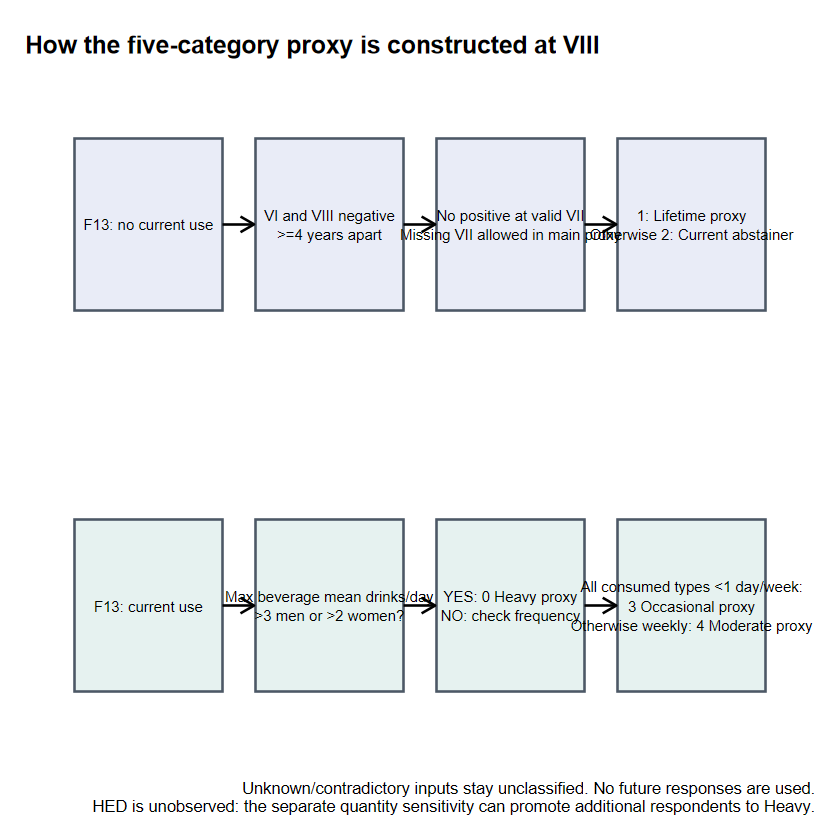

In [12]:
#| label: eps-classification-map
.t0 <- Sys.time()
flow_nodes <- data.frame(x = c(0, 3, 6, 9, 0, 3, 6, 9), y = c(2, 2, 2, 2, 0, 0, 0, 0),
  text = c("F13: no current use", "VI and VIII negative\n>=4 years apart", "No positive at valid VII\nMissing VII allowed in main proxy",
    "1: Lifetime proxy\nOtherwise 2: Current abstainer",
    "F13: current use", "Max beverage mean drinks/day\n>3 men or >2 women?",
    "YES: 0 Heavy proxy\nNO: check frequency", "All consumed types <1 day/week:\n3 Occasional proxy\nOtherwise weekly: 4 Moderate proxy"))
flow_edges <- data.frame(x = rep(c(1.23, 4.23, 7.23), 2), xend = rep(c(1.75, 4.75, 7.75), 2), y = rep(c(2, 0), each = 3))
eps_flow <- ggplot2::ggplot() +
  ggplot2::geom_rect(data = flow_nodes, ggplot2::aes(xmin = x - 1.23, xmax = x + 1.23, ymin = y - .45, ymax = y + .45),
    fill = rep(c("#e9ecf7", "#e6f2f0"), each = 4), colour = "#4c5866") +
  ggplot2::geom_text(data = flow_nodes, ggplot2::aes(x, y, label = text), size = 3.05, lineheight = 1.12) +
  ggplot2::geom_segment(data = flow_edges, ggplot2::aes(x = x, xend = xend, y = y, yend = y),
    arrow = grid::arrow(length = grid::unit(.13, "inches"))) +
  ggplot2::coord_cartesian(xlim = c(-1.45, 10.45), ylim = c(-.7, 2.7), clip = "off") +
  ggplot2::theme_void(base_size = 12) + ggplot2::labs(title = "How the five-category proxy is constructed at VIII",
    caption = "Unknown/contradictory inputs stay unclassified. No future responses are used.\nHED is unobserved: the separate quantity sensitivity can promote additional respondents to Heavy.") +
  ggplot2::theme(plot.background = ggplot2::element_rect(fill = "white", colour = NA), plot.title = ggplot2::element_text(face = "bold"), plot.margin = ggplot2::margin(15, 15, 15, 15))
print(eps_flow)
ggplot2::ggsave(file.path(eps_out, "calvo_classification_map.png"), eps_flow, width = 15, height = 5.2, dpi = 180, bg = "white")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

## 7. Empirical persistence and rho for the microsimulation

\(P(D_1=1\mid D_0=1)\), \(P(D_1=0\mid D_0=0)\), initiation/reinitiation, observed cessation, the unchanged fraction and Pearson's binary correlation are estimated separately. **None is automatically the engine's rho.** “Initiation” cannot distinguish first-ever initiation from relapse.

The Chilean engine uses \(Z_{t+1}=\rho Z_t+\sqrt{1-\rho^2}\epsilon\), with drinking when \(\Phi(Z_t)<p_t\). To approximate its participation component, a tetrachoric correlation \(r_\Delta\) is fitted to the weighted 2×2 table:

\[
P(D_0=1,D_1=1)=\Phi_2\{\Phi^{-1}(p_0),\Phi^{-1}(p_1);r_\Delta\}.
\]

Marginal prevalence is allowed to change. The equation is solved numerically; uncertainty uses the function's gradient and the survey-design variance–covariance matrix, with confidence intervals on the Fisher-z scale. Rho is not estimated for tables with empty cells or constant margins. Small cells are flagged rather than stabilized with invented counts.

**Conditional annualization:** \(\rho_{annual}=r_\Delta^{1/\Delta}\), only for positive association and under a homogeneous Gaussian AR(1), comparable measurement and stationary temporal dependence. Approximate fieldwork midpoints are used, with endpoint sensitivities shown. The sampling confidence interval at fixed Δ excludes measurement and selection uncertainty; the fieldwork timing envelope is exported separately.

This rho can inform **`z_current`**; it does not automatically identify `z_amount` or `z_hed`. Pooled rho contains stable differences between people, so estimates are compared by sex, baseline age and education. Selection of survivors and interviewable respondents is not eliminated by a longitudinal weight. Results are not automatically inserted into the engine. Rho is also distinct from `hed_exit_shift`, which denotes the volume fraction retained in the PIF calculation.


In [13]:
#| label: eps-persistence
.t0 <- Sys.time()
eps_bvn <- function(p0, p1, rho) as.numeric(mvtnorm::pmvnorm(upper = stats::qnorm(c(p0, p1)),
    corr = matrix(c(1, rho, rho, 1), 2), algorithm = mvtnorm::Miwa(steps = 128L)))
eps_tetra <- function(p) {
  p <- p / sum(p) # Order: 00, 01, 10, 11; normalize also for numerical derivatives.
  if (any(!is.finite(p)) || any(p <= 0)) return(NA_real_)
  p0 <- p[3] + p[4]; p1 <- p[2] + p[4]
  fn <- function(r) eps_bvn(p0, p1, r) - p[4]
  if (fn(-.999) * fn(.999) >= 0) return(NA_real_)
  stats::uniroot(fn, c(-.999, .999), tol = 1e-7)$root
}
eps_rho <- function(ds, delta, delta_min, delta_max) {
  d <- ds$variables; ok <- stats::complete.cases(d[c("current0", "current1")])
  ds <- ds[ok, ]; d <- ds$variables
  empty <- data.frame(n = nrow(d), n_eff = NA_real_, phi = NA_real_, rho_interval = NA_real_, lower = NA_real_, upper = NA_real_,
    rho_annual = NA_real_, annual_lower = NA_real_, annual_upper = NA_real_, annual_time_min = NA_real_, annual_time_max = NA_real_, flag = "empty_or_zero_cell")
  if (!nrow(d)) return(empty)
  cell <- 1L + d$current1 + 2L * d$current0
  for (j in 1:4) ds$variables[[paste0("p", j)]] <- as.numeric(cell == j)
  stat <- survey::svymean(~p1 + p2 + p3 + p4, ds)
  p <- unname(stats::coef(stat)); V <- stats::vcov(stat); ne <- sum(d$weight)^2 / sum(d$weight^2)
  r <- eps_tetra(p); empty$n_eff <- ne
  p0 <- p[3] + p[4]; p1 <- p[2] + p[4]
  phi <- (p[4] - p0 * p1) / sqrt(p0 * (1 - p0) * p1 * (1 - p1))
  empty$phi <- phi
  if (!is.finite(r)) return(empty)
  h <- min(1e-5, min(p) / 4)
  grad <- vapply(1:4, function(j) { a <- b <- p; a[j] <- a[j] + h; b[j] <- b[j] - h; (eps_tetra(a) - eps_tetra(b)) / (2 * h) }, numeric(1))
  se <- sqrt(max(0, as.numeric(t(grad) %*% V %*% grad)))
  df <- survey::degf(ds)
  ci <- if (df > 0 && is.finite(se)) tanh(atanh(r) + c(-1, 1) * stats::qt(.975, df) * se / (1 - r^2)) else c(NA_real_, NA_real_)
  ann <- function(x, dt) ifelse(is.finite(x) & x > 0, pmax(x, 0)^(1 / dt), NA_real_)
  flag <- if (ne < 50 || min(table(factor(cell, levels = 1:4))) < 5 || df < 8) "sparse_or_low_df" else if (r <= 0) "nonpositive_no_annual_AR1" else "conditional_AR1_only"
  data.frame(n = nrow(d), n_eff = ne, phi, rho_interval = r, lower = ci[1], upper = ci[2], rho_annual = ann(r, delta),
    annual_lower = ann(ci[1], delta), annual_upper = ann(ci[2], delta),
    annual_time_min = ann(r, delta_min), annual_time_max = ann(r, delta_max), flag)
}
eps_panel_groups <- function(d, education = FALSE) {
  # Main pooled estimates are for 50+ at baseline, matching the Calvo target domain.
  groups <- list(list(key = data.frame(age_group = "50+", sex = "All", education = "All"), keep = d$age >= 50))
  for (sx in c("Men", "Women")) groups[[length(groups) + 1L]] <- list(key = data.frame(age_group = "50+", sex = sx, education = "All"), keep = d$age >= 50 & d$sex == sx)
  c(groups, eps_domains(d, education = education))
}
eps_rho_table <- do.call(rbind, lapply(names(eps_pairs), function(p) {
  ds <- eps_pair_designs[[p]]; tm <- eps_time[eps_time$pair == p, ]
  do.call(rbind, lapply(eps_panel_groups(ds$variables), function(g) cbind(pair = p, g$key,
    eps_rho(ds[which(g$keep), ], tm$delta, tm$delta_min, tm$delta_max))))
}))
eps_rho_education <- do.call(rbind, lapply(names(eps_pairs), function(p) {
  ds <- eps_pair_designs[[p]]; tm <- eps_time[eps_time$pair == p, ]
  do.call(rbind, lapply(eps_domains(ds$variables, education = TRUE), function(g) cbind(pair = p, g$key,
    eps_rho(ds[which(g$keep), ], tm$delta, tm$delta_min, tm$delta_max))))
}))
eps_transitions <- do.call(rbind, lapply(names(eps_pairs), function(p) {
  ds <- eps_pair_designs[[p]]
  do.call(rbind, lapply(eps_panel_groups(ds$variables), function(g) {
    s <- ds[which(g$keep), ]; d <- s$variables; ok <- stats::complete.cases(d[c("current0", "current1")])
    rows <- lapply(c(0, 1), function(origin) lapply(c(0, 1), function(destination) {
      ss <- s[which(ok & d$current0 == origin), ]
      cbind(pair = p, g$key, origin, destination, eps_prop(ss, as.numeric(ss$variables$current1 == destination)))
    }))
    do.call(rbind, unlist(rows, recursive = FALSE))
  }))
}))
eps_baseline_pair <- eps_make_pair("VIII", baseline_weights = TRUE)
eps_baseline_pair_design <- eps_design(eps_baseline_pair, weights_only = TRUE)
bp <- eps_baseline_pair_design[eps_baseline_pair_design$variables$age >= 50, ]
eps_rho_weight_sensitivity <- cbind(weighting = "baseline_weight_endpoint_respondents_not_attrition_corrected",
  eps_rho(bp, 7.693, 7.110, 8.277))
eps_save(eps_rho_table, "rho_age_sex"); eps_save(eps_rho_education, "rho_age_sex_education")
eps_save(eps_transitions, "binary_transitions"); eps_save(eps_rho_weight_sensitivity, "rho_weight_sensitivity")
eps_table(subset(eps_rho_table, age_group == "50+")[, c("pair", "sex", "n", "rho_interval", "lower", "upper", "rho_annual", "annual_time_min", "annual_time_max", "flag")],
          "Rho: observed latent association and annual transformation conditional on AR(1)")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

pair,sex,n,rho_interval,lower,upper,rho_annual,annual_time_min,annual_time_max,flag
VI_VII,All,2613,0.546,0.484,0.603,0.848,0.832,0.862,conditional_AR1_only
VI_VII,Men,1105,0.525,0.424,0.613,0.839,0.822,0.853,conditional_AR1_only
VI_VII,Women,1508,0.425,0.330,0.511,0.792,0.771,0.810,conditional_AR1_only
VI_VIII,All,2543,0.485,0.411,0.553,0.910,0.903,0.916,conditional_AR1_only
VI_VIII,Men,1034,0.423,0.304,0.529,0.894,0.886,0.901,conditional_AR1_only
VI_VIII,Women,1509,0.449,0.342,0.544,0.901,0.893,0.908,conditional_AR1_only


Elapsed: 0.05 minutes


### 7.0. Beverage-specific persistence

The same latent-correlation estimator is also fitted to beer, wine and spirits separately, using each type's F13 response at the two interviews. This measures persistence of **using that beverage**, with age at baseline and the original longitudinal weights. It does not identify persistence of its amount or of HED. Sparse and empty 2-by-2 tables remain flagged. Switching beverages can coexist with stable any-alcohol use.

In [14]:
#| label: eps-beverage-persistence
.t0 <- Sys.time()
eps_beverage_rho <- do.call(rbind, lapply(names(eps_pairs), function(p) {
  d <- eps_pairs[[p]]; tm <- eps_time[eps_time$pair == p, ]
  before <- eps_beverage_use(eps_data$VI[match(d$id, eps_data$VI$id), ])
  after_data <- eps_data[[tm$to]][match(d$id, eps_data[[tm$to]]$id), ]
  after_use <- eps_beverage_use(after_data)
  do.call(rbind, lapply(eps_beverage_names, function(beverage) {
    ds <- eps_pair_designs[[p]]
    ds$variables$current0 <- ifelse(d$good_link, before[[beverage]], NA_real_)
    ds$variables$current1 <- ifelse(d$good_link, after_use[[beverage]], NA_real_)
    do.call(rbind, lapply(eps_panel_groups(d), function(g)
      cbind(pair = p, beverage, g$key, eps_rho(ds[which(g$keep), ], tm$delta, tm$delta_min, tm$delta_max))))
  }))
}))
eps_save(eps_beverage_rho, "rho_beverage_age_sex")
eps_table(subset(eps_beverage_rho, age_group == "50+" & sex == "All")[,
  c("pair", "beverage", "n", "rho_interval", "lower", "upper", "rho_annual", "flag")],
  "Beverage-specific persistence: age 50+ at baseline; annual values are conditional transformations")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

pair,beverage,n,rho_interval,lower,upper,rho_annual,flag
VI_VII,Beer,2616,0.613,0.539,0.677,0.875,conditional_AR1_only
VI_VII,Wine,2618,0.549,0.486,0.607,0.849,conditional_AR1_only
VI_VII,Spirits,2620,0.614,0.503,0.705,0.876,conditional_AR1_only
VI_VIII,Beer,2545,0.498,0.426,0.564,0.913,conditional_AR1_only
VI_VIII,Wine,2547,0.469,0.387,0.544,0.906,conditional_AR1_only
VI_VIII,Spirits,2547,0.436,0.304,0.552,0.898,conditional_AR1_only


Elapsed: 0.05 minutes


### 7.1. Checking the annual assumption in the same people

The analysis takes the VI–VIII panel subdomain with a VII **in-person** interview and known status at all three interviews, retaining the official VIII weight. All three intervals are compared in exactly the same people. This selection remains conditional on the in-person mode and is not an attrition correction. Under a homogeneous AR(1) without additional heterogeneity, the tetrachoric correlations should approximately satisfy \(r_{VI,VIII}=r_{VI,VII}r_{VII,VIII}\). The discrepancy is reported as a descriptive diagnostic, **without an independence test or p-value** for these correlated estimates.

Outputs also include transitions among the four classifiable JRT-oriented reference states and the prevalence of VIII abstinence with previously observed use. The latter provides a **lower bound on former drinking identified from observed history**. Incomplete history remains unresolved for true lifetime status, while the separately labelled Calvo lifetime-abstainer proxy follows the operational rule in section 6.1. Widely spaced interviews do not measure the continuous duration of abstinence.


In [15]:
#| label: eps-panel-diagnostics
.t0 <- Sys.time()
td <- eps_pairs$VI_VIII
mid_match <- match(td$id, eps_data$VII_presencial$id)
mid_data <- eps_data$VII_presencial[mid_match, ]
td$current_mid <- mid_data$current
mid_good <- !is.na(mid_match) & mid_data$sex == td$sex &
  mid_data$age - td$age >= 3 & mid_data$age - td$age <= 5 &
  td$age_end - mid_data$age >= 3 & td$age_end - mid_data$age <= 5
td$triple_valid <- td$good_link & !is.na(mid_good) & mid_good &
  stats::complete.cases(td[c("current0", "current_mid", "current1")])
triple_design <- eps_design(td)
eps_triple_rho <- do.call(rbind, lapply(c("All", "Men", "Women"), function(sx) {
  ds <- triple_design[which(td$triple_valid & td$age >= 50 & (sx == "All" | td$sex == sx)), ]
  long <- eps_rho(ds, 7.693, 7.110, 8.277)
  first <- ds; first$variables$current1 <- first$variables$current_mid
  second <- ds; second$variables$current0 <- second$variables$current_mid
  rbind(cbind(sex = sx, pair = "VI_VII_same_people", eps_rho(first, 3.671, 3.285, 4.057)),
        cbind(sex = sx, pair = "VII_VIII_same_people", eps_rho(second, 4.022, 3.554, 4.490)),
        cbind(sex = sx, pair = "VI_VIII_same_people", long))
}))
eps_ar1_diagnostic <- do.call(rbind, lapply(split(eps_triple_rho, eps_triple_rho$sex), function(d) {
  first <- d$rho_interval[d$pair == "VI_VII_same_people"]
  second <- d$rho_interval[d$pair == "VII_VIII_same_people"]
  long <- d$rho_interval[d$pair == "VI_VIII_same_people"]
  data.frame(sex = d$sex[1], n = d$n[1], interval_first = first, interval_second = second,
    long_observed = long, long_implied_product = first * second, discrepancy = long - first * second,
    interpretation = "descriptive_same_people_not_a_formal_test")
}))
eps_state_transitions <- do.call(rbind, lapply(names(eps_pairs), function(p) {
  ds <- eps_pair_designs[[p]]; d <- ds$variables
  do.call(rbind, lapply(c("Men", "Women"), function(sx) do.call(rbind, lapply(eps_states, function(origin) {
    ss <- ds[which(d$age >= 50 & d$sex == sx & d$state0 == origin), ]
    do.call(rbind, lapply(eps_states, function(destination) {
      z <- ss$variables$state1
      cbind(pair = p, sex = sx, origin, destination, eps_prop(ss, ifelse(is.na(z), NA_real_, as.numeric(z == destination))))
    }))
  }))))
}))
eps_stay <- do.call(rbind, lapply(names(eps_pairs), function(p) {
  ds <- eps_pair_designs[[p]]; d <- ds$variables
  do.call(rbind, lapply(c("All", "Men", "Women"), function(sx) {
    ss <- ds[which(d$age >= 50 & (sx == "All" | d$sex == sx)), ]; v <- ss$variables
    cbind(pair = p, sex = sx, eps_prop(ss, as.numeric(v$current0 == v$current1)))
  }))
}))
eps_lifetime_bounds <- do.call(rbind, lapply(c("Men", "Women"), function(sx) {
  ds <- hd[which(hd$variables$sex == sx & hd$variables$age >= 50), ]; d <- ds$variables
  mm <- d$current_mid
  prior_positive <- (!is.na(d$current0) & d$current0 == 1) | (!is.na(mm) & mm == 1)
  known_former <- !is.na(d$current1) & d$current1 == 0 & prior_positive
  possible_lifetime <- (is.na(d$current1) | d$current1 == 0) & !prior_positive
  data.frame(sex = sx, domain = "50plus_at_VI_official_panel", n = nrow(d), lifetime_lower = 0,
    lifetime_upper = stats::weighted.mean(as.numeric(possible_lifetime), d$weight),
    observed_former_lower = stats::weighted.mean(as.numeric(known_former), d$weight),
    note = "identification_bounds_not_confidence_intervals")
}))
eps_save(eps_triple_rho, "rho_same_people_three_interviews"); eps_save(eps_ar1_diagnostic, "ar1_same_people_diagnostic")
eps_save(eps_state_transitions, "category_transitions_50plus"); eps_save(eps_stay, "unchanged_status_50plus")
eps_save(eps_lifetime_bounds, "lifetime_identification_bounds_panel")
eps_table(eps_ar1_diagnostic[, 1:7], "AR(1) diagnostic: the same subpanel, age 50+ at baseline; not a formal test")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

sex,n,interval_first,interval_second,long_observed,long_implied_product,discrepancy
All,1744,0.566,0.588,0.478,0.333,0.145
Men,684,0.587,0.541,0.405,0.317,0.088
Women,1060,0.432,0.562,0.469,0.243,0.226


Elapsed: 0.02 minutes


## 8. Figures and checks that can fail

Figures distinguish reported-use prevalence from volume-based classification and from the separate Calvo-style proxy categories. The two longitudinal comparisons retain their respective populations and interview intervals; a difference between them does not by itself demonstrate a population change in persistence.

Checks cover structural skips, frequency code zero among drinkers, non-response codes, sex-specific heavy-drinking boundaries, changed education codes, independence and a known rho. Real-data checks verify category sums, probabilities, links and the exclusion of 2012 from the alcohol analysis. These checks assess implementation; passing them does not validate the standard-drink conversion, AR(1), comparability, selection assumptions or the proxy's equivalence to true lifetime abstinence.


In [16]:
#| label: eps-checks
.t0 <- Sys.time()
# One compact runnable check covers the nontrivial derivation and latent-correlation inversion.
ss <- rbind(c(2,2,2), c(1,2,2), c(1,2,2), c(1,2,2), c(1,2,2), c(1,2,2), c(2,8,2))
ff <- rbind(c(NA,NA,NA), c(0,NA,NA), c(7,NA,NA), c(7,NA,NA), c(1,NA,NA), c(1,NA,NA), c(NA,NA,NA))
qq <- rbind(c(NA,NA,NA), c(1,NA,NA), c(40/12,NA,NA), c(60/12,NA,NA), c(888,NA,NA), c(0,NA,NA), c(NA,NA,NA))
zz <- eps_alcohol(ss, ff, qq, c("Women", "Women", "Women", "Men", "Women", "Men", "Women"))
stopifnot(zz$current[1] == 0, zz$grams_day[1] == 0, zz$current[2] == 1, zz$grams_day[2] > 0,
  zz$state[2] == eps_states[2], all(zz$state[3:4] == "Heavy"), all(is.na(zz$grams_day[5:7])), is.na(zz$current[7]))
stopifnot(eps_education(11, NA, 2, "VI") == eps_edu_levels[3],
          eps_education(11, NA, 3, "VI") == eps_edu_levels[2],
          eps_education(11, NA, 3, "VIII") == eps_edu_levels[3],
          eps_education(6, 2, NA, "VIII") == eps_edu_levels[1])
for (known in c(0, .3, .8)) {
  joint <- eps_bvn(.4, .55, known)
  probs <- c(1-.4-.55+joint, .55-joint, .4-joint, joint)
  stopifnot(abs(eps_tetra(probs) - known) < 1e-5)
}
stopifnot(abs((.8^4)^(1/4) - .8) < 1e-12, is.na(eps_tetra(c(.5,0,0,.5))))
cats <- subset(eps_prevalence_main, outcome != "Declared current use")
sums <- stats::aggregate(estimate ~ wave + age_group + sex, cats, sum)
stopifnot(all(abs(sums$estimate - 1) < 1e-8), all(eps_prevalence_main$estimate >= 0 & eps_prevalence_main$estimate <= 1, na.rm = TRUE),
  all(eps_prevalence_main$bound_lower <= eps_prevalence_main$bound_upper),
  all(eps_prevalence_main$estimate >= eps_prevalence_main$bound_lower - 1e-10 & eps_prevalence_main$estimate <= eps_prevalence_main$bound_upper + 1e-10, na.rm = TRUE),
  all(is.na(eps_requested$estimate[grepl("Lifetime", eps_requested$outcome)])),
  !anyDuplicated(eps_data$VIII$id), !any(grepl("2012", names(eps_data))))
trsum <- stats::aggregate(estimate ~ pair + age_group + sex + education + origin, eps_transitions, sum)
stopifnot(all(abs(trsum$estimate - 1) < 1e-8), all(abs(eps_rho_table$rho_interval) < 1, na.rm = TRUE))
csum <- stats::aggregate(estimate ~ pair + sex + origin, eps_state_transitions, sum)
stopifnot(all(abs(csum$estimate - 1) < 1e-8), all(eps_lifetime_bounds$lifetime_upper >= 0 & eps_lifetime_bounds$lifetime_upper <= 1),
          all(vapply(split(eps_triple_rho$n, eps_triple_rho$sex), function(x) length(unique(x)) == 1L, logical(1))))
for (p in names(eps_pairs)) {
  d <- eps_pairs[[p]]; tm <- eps_time[eps_time$pair == p, ]
  stopifnot(all(d$age_end[d$good_link] - d$age[d$good_link] >= floor(tm$delta_min)),
            all(d$age_end[d$good_link] - d$age[d$good_link] <= ceiling(tm$delta_max)))
}
eps_checks <- data.frame(check = c("skip_missing_frequency_boundaries", "education_code_change", "known_tetrachoric_rho", "category_and_transition_sums", "lifetime_not_fabricated", "unique_real_data_links"), result = "PASS")
eps_save(eps_checks, "validation_checks")

# The Calvo branch must honor strict thresholds, observed history, missingness and the distinct denominator.
history_test <- eps_lifetime_proxy(c(0,0,1,0,0), c(NA,1,0,0,0), rep(0,5), rep(TRUE,5), c(7,7,7,3.99,4))
stopifnot(identical(history_test, c(TRUE,FALSE,FALSE,FALSE,TRUE)),
  !eps_lifetime_proxy(0, NA, 0, TRUE, 7, strict = TRUE),
  eps_lifetime_proxy(0, 0, 0, TRUE, 7, strict = TRUE),
  all(!eps_cp$lifetime_strict | eps_cp$lifetime_proxy),
  !any(eps_cp$lifetime_proxy & eps_cp$current_mid == 1, na.rm = TRUE))
test_d <- data.frame(sex = c("Men", "Men", "Women", "Women", "Men", "Men", "Men"),
  f13_1 = 1, f13_2 = 2, f13_3 = 2,
  f14_1 = c(7,7,7,7,0,1,1), f14_2 = NA_real_, f14_3 = NA_real_,
  f15_1 = c(3,3.01,2,2.01,1,6,888), f15_2 = NA_real_, f15_3 = NA_real_)
z <- eps_calvo_classify(test_d); zq <- eps_calvo_classify(test_d, quantity_proxy = TRUE)
stopifnot(identical(z$code, c(4L,0L,4L,0L,3L,4L,NA_integer_)),
  zq$code[6] == 0L, is.na(zq$code[7]), is.na(z$typical_high_quantity[7]))
cps <- stats::aggregate(estimate ~ scenario + age_group + sex + education, eps_calvo_prevalence, sum)
stopifnot(all(abs(cps$estimate - 1) < 1e-8), all(abs(eps_beverage_rho$rho_interval) < 1, na.rm = TRUE))
for (w in names(eps_data)) {
  use <- do.call(cbind, eps_beverage_use(eps_data[[w]]))
  stopifnot(all(eps_data[[w]]$current[rowSums(use == 1, na.rm = TRUE) > 0] == 1),
    all(eps_data[[w]]$current[rowSums(use == 0, na.rm = TRUE) == 3] == 0))
}
eps_checks <- rbind(eps_checks, data.frame(check = c("calvo_strict_thresholds_and_HED_proxy", "four_year_history_no_positive", "five_proxy_categories_sum", "beverage_use_and_rho"), result = "PASS"))
eps_save(eps_checks, "validation_checks")


enpg_shares <- subset(enpg_preferred_beverage, outcome == "Most frequent beverage share")
enpg_share_sums <- stats::aggregate(estimate ~ age_group + sex, enpg_shares, sum)
stopifnot(all(abs(enpg_share_sums$estimate - 1) < 1e-8),
  all(is.na(enpg_prevalence$estimate[enpg_prevalence$flag == "outside_ENPG_age_support"])))
eps_checks <- rbind(eps_checks, data.frame(check = c("ENPG_skip_missing_HED_age_support", "ENPG_preferred_beverage_shares_sum"), result = "PASS"))
eps_save(eps_checks, "validation_checks")
eps_table(eps_checks, "Validation executed on synthetic cases and real data")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

check,result
skip_missing_frequency_boundaries,PASS
education_code_change,PASS
known_tetrachoric_rho,PASS
category_and_transition_sums,PASS
lifetime_not_fabricated,PASS
unique_real_data_links,PASS
calvo_strict_thresholds_and_HED_proxy,PASS
four_year_history_no_positive,PASS
five_proxy_categories_sum,PASS
beverage_use_and_rho,PASS


Elapsed: 0.00 minutes


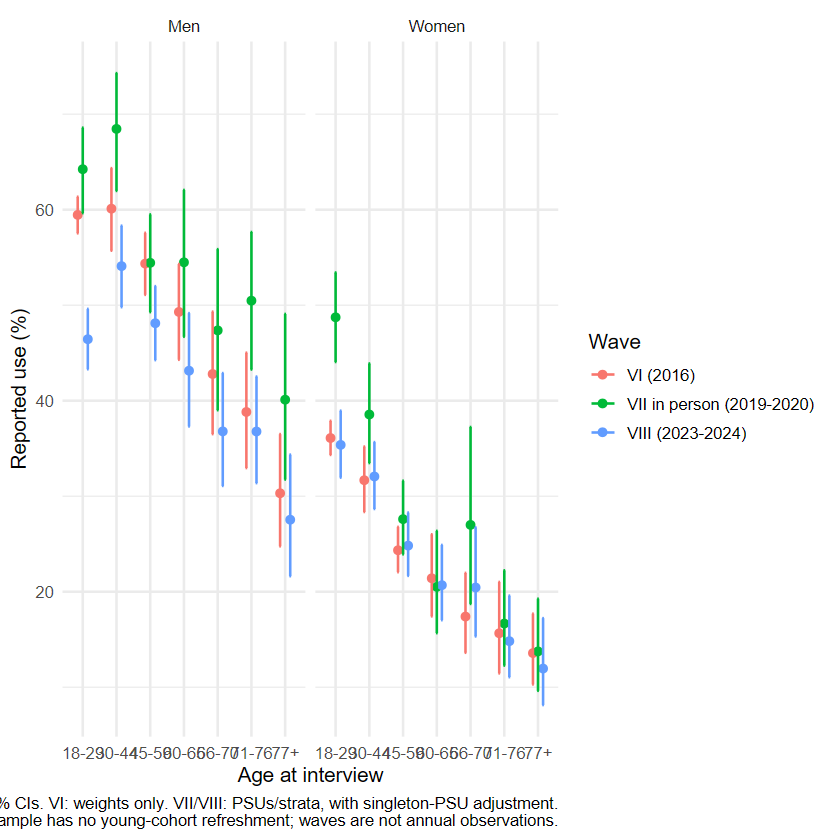

Elapsed: 0.01 minutes


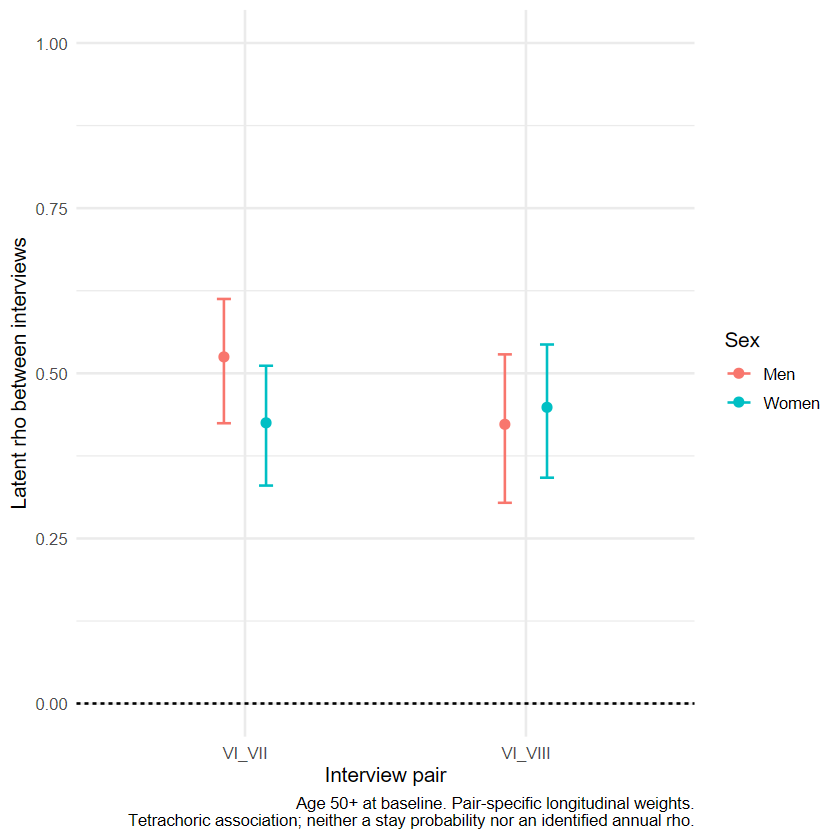

In [17]:
#| label: eps-figures
.t0 <- Sys.time()
eps_plot_data <- subset(eps_prevalence_main, outcome == "Declared current use")
eps_plot_data$age_group <- factor(eps_plot_data$age_group, levels = eps_age_levels)
eps_plot_data$wave <- factor(eps_plot_data$wave, levels = names(eps_data),
  labels = c("VI (2016)", "VII in person (2019-2020)", "VIII (2023-2024)"))
eps_plot <- ggplot2::ggplot(eps_plot_data, ggplot2::aes(age_group, estimate * 100, colour = wave, group = wave)) +
  ggplot2::geom_point(position = ggplot2::position_dodge(.45)) +
  ggplot2::geom_errorbar(ggplot2::aes(ymin = lower * 100, ymax = upper * 100), width = .15, position = ggplot2::position_dodge(.45)) +
  ggplot2::facet_wrap(~sex) + ggplot2::theme_minimal(base_size = 12) +
  ggplot2::labs(x = "Age at interview", y = "Reported use (%)", colour = "Wave",
    caption = "F13; approximate 95% CIs. VI: weights only. VII/VIII: PSUs/strata, with singleton-PSU adjustment.\nVII in-person sample has no young-cohort refreshment; waves are not annual observations.")
print(eps_plot)
ggplot2::ggsave(file.path(eps_out, "prevalence_age_sex.png"), eps_plot, width = 10, height = 5.3, dpi = 180, bg = "white")
eps_rp <- subset(eps_rho_table, age_group == "50+" & sex != "All")
eps_rho_plot <- ggplot2::ggplot(eps_rp, ggplot2::aes(pair, rho_interval, colour = sex)) +
  ggplot2::geom_point(position = ggplot2::position_dodge(.3), size = 2) +
  ggplot2::geom_errorbar(ggplot2::aes(ymin = lower, ymax = upper), width = .1, position = ggplot2::position_dodge(.3)) +
  ggplot2::geom_hline(yintercept = 0, linetype = 2) + ggplot2::coord_cartesian(ylim = c(0, 1)) +
  ggplot2::theme_minimal(base_size = 12) + ggplot2::labs(x = "Interview pair", y = "Latent rho between interviews", colour = "Sex",
    caption = "Age 50+ at baseline. Pair-specific longitudinal weights.\nTetrachoric association; neither a stay probability nor an identified annual rho.")
print(eps_rho_plot)
ggplot2::ggsave(file.path(eps_out, "rho_between_interviews.png"), eps_rho_plot, width = 8, height = 4.7, dpi = 180, bg = "white")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

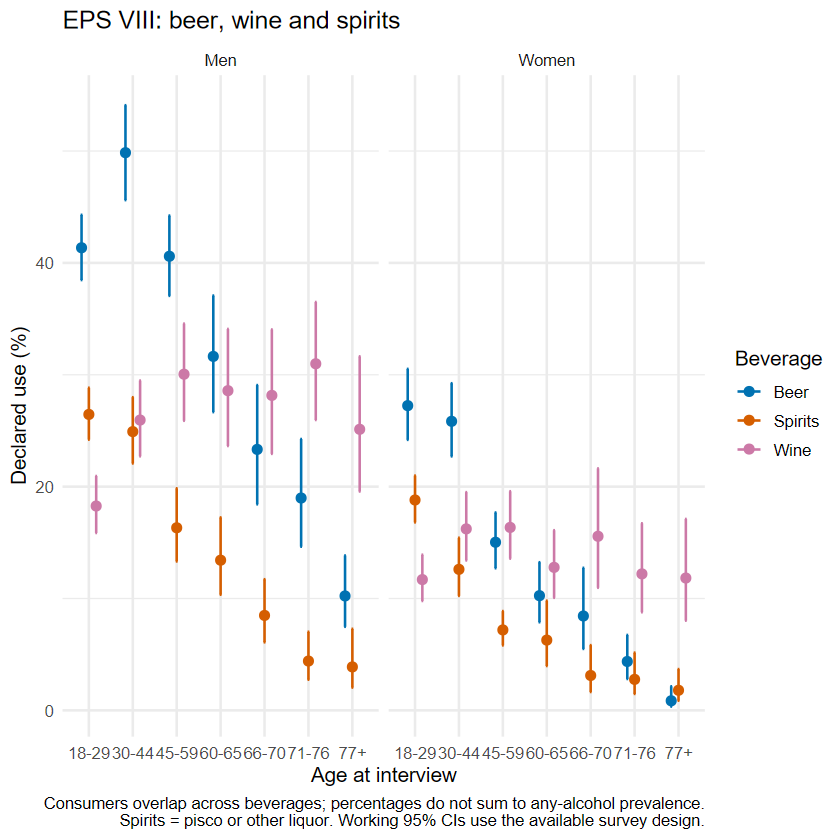

Elapsed: 0.02 minutes


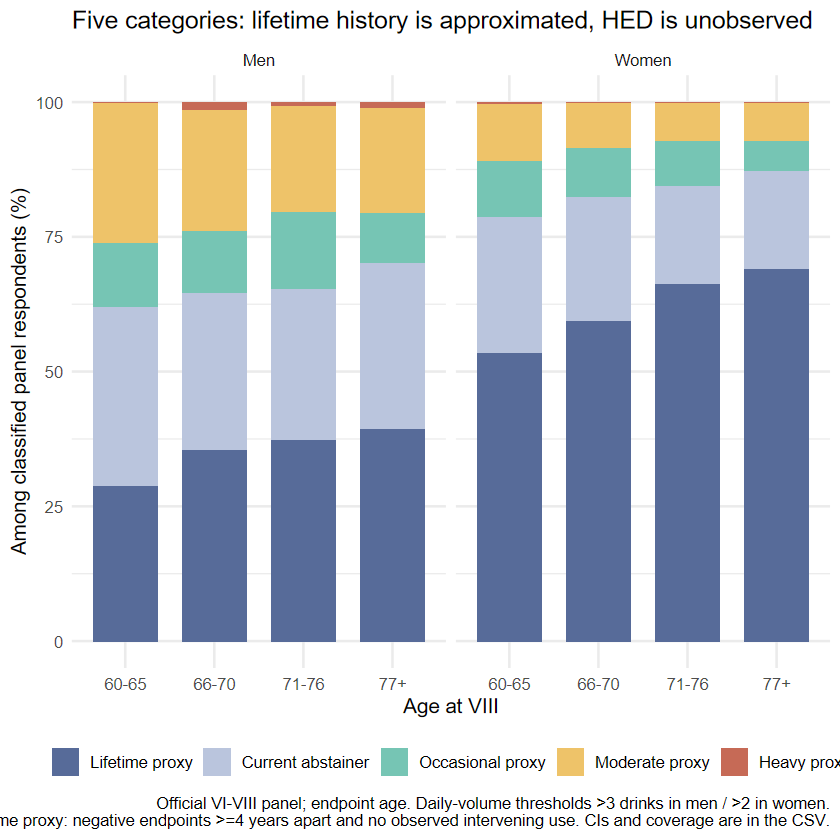

In [18]:
#| label: eps-additional-figures
.t0 <- Sys.time()
bp <- subset(eps_beverage_prevalence, wave == "VIII")
bp$age_group <- factor(bp$age_group, levels = eps_age_levels)
eps_beverage_plot <- ggplot2::ggplot(bp, ggplot2::aes(age_group, estimate * 100, colour = outcome)) +
  ggplot2::geom_point(position = ggplot2::position_dodge(.5), size = 2) +
  ggplot2::geom_errorbar(ggplot2::aes(ymin = lower * 100, ymax = upper * 100), width = .12,
    position = ggplot2::position_dodge(.5)) + ggplot2::facet_wrap(~sex) +
  ggplot2::scale_colour_manual(values = c(Beer = "#0072B2", Wine = "#CC79A7", Spirits = "#D55E00")) +
  ggplot2::theme_minimal(base_size = 12) + ggplot2::labs(x = "Age at interview", y = "Declared use (%)", colour = "Beverage",
    title = "EPS VIII: beer, wine and spirits",
    caption = "Consumers overlap across beverages; percentages do not sum to any-alcohol prevalence.\nSpirits = pisco or other liquor. Working 95% CIs use the available survey design.")
print(eps_beverage_plot)
ggplot2::ggsave(file.path(eps_out, "beverage_prevalence_VIII.png"), eps_beverage_plot, width = 11, height = 5.8, dpi = 180, bg = "white")
cp <- subset(eps_calvo_prevalence, scenario == "Calvo_volume_only_proxy" & education == "All" &
  age_group %in% c("60-65", "66-70", "71-76", "77+"))
cp$outcome <- factor(cp$outcome, levels = eps_calvo_labels)
eps_calvo_plot <- ggplot2::ggplot(cp, ggplot2::aes(age_group, estimate * 100, fill = outcome)) +
  ggplot2::geom_col(width = .72, position = ggplot2::position_stack(reverse = TRUE)) + ggplot2::facet_wrap(~sex) +
  ggplot2::scale_fill_manual(values = c("#576b99", "#bac5dd", "#76c5b4", "#eec369", "#c66a56"),
    labels = c("Lifetime proxy", "Current abstainer", "Occasional proxy", "Moderate proxy", "Heavy proxy")) +
  ggplot2::theme_minimal(base_size = 12) + ggplot2::labs(x = "Age at VIII", y = "Among classified panel respondents (%)", fill = "Calvo approximation",
    title = "Five categories: lifetime history is approximated, HED is unobserved",
    caption = "Official VI-VIII panel; endpoint age. Daily-volume thresholds >3 drinks in men / >2 in women.\nLifetime proxy: negative endpoints >=4 years apart and no observed intervening use. CIs and coverage are in the CSV.") +
  ggplot2::theme(legend.position = "bottom", legend.title = ggplot2::element_blank())
print(eps_calvo_plot)
ggplot2::ggsave(file.path(eps_out, "calvo_five_categories_VIII_panel.png"), eps_calvo_plot, width = 12, height = 6, dpi = 180, bg = "white")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

Elapsed: 0.01 minutes


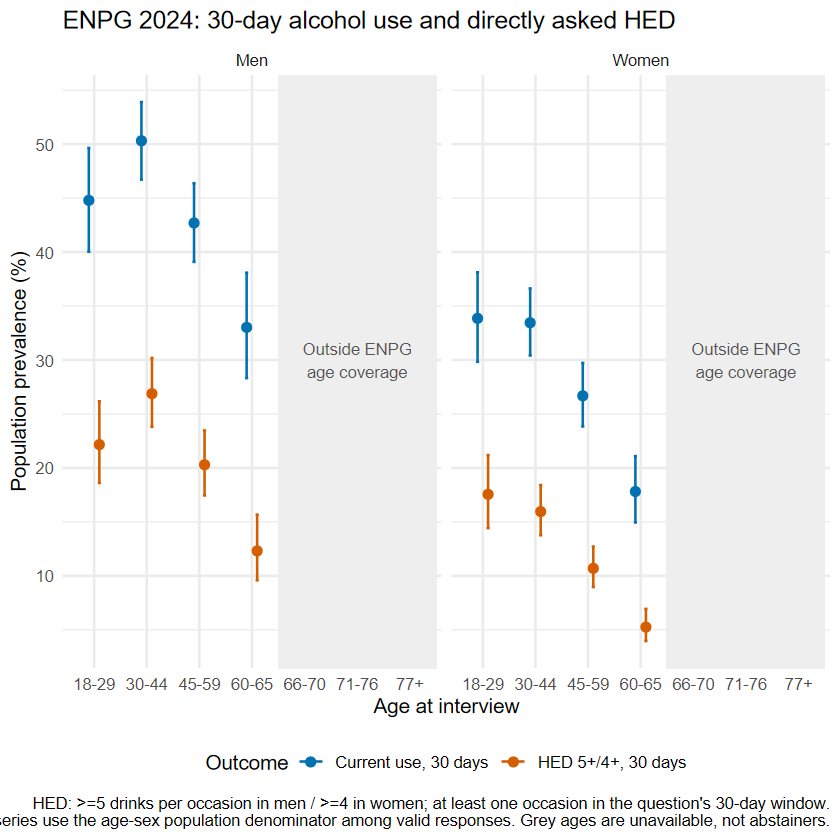

In [19]:
#| label: enpg-figure
.t0 <- Sys.time()
np <- subset(enpg_prevalence, denominator == "Age-sex population" & age_group != "15-17")
np$age_group <- factor(np$age_group, levels = eps_age_levels)
enpg_plot <- ggplot2::ggplot(np, ggplot2::aes(age_group, estimate * 100, colour = outcome)) +
  ggplot2::annotate("rect", xmin = 4.5, xmax = 7.5, ymin = -Inf, ymax = Inf, fill = "#eeeeee", colour = NA) +
  ggplot2::geom_point(position = ggplot2::position_dodge(.4), size = 2, na.rm = TRUE) +
  ggplot2::geom_errorbar(ggplot2::aes(ymin = lower * 100, ymax = upper * 100), width = .12,
    position = ggplot2::position_dodge(.4), na.rm = TRUE) + ggplot2::facet_wrap(~sex) +
  ggplot2::scale_x_discrete(drop = FALSE) + ggplot2::scale_colour_manual(values = c("#0072B2", "#D55E00")) +
  ggplot2::annotate("text", x = 6, y = 30, label = "Outside ENPG\nage coverage", colour = "#555555", size = 3.4) +
  ggplot2::theme_minimal(base_size = 12) + ggplot2::labs(x = "Age at interview", y = "Population prevalence (%)", colour = "Outcome",
    title = "ENPG 2024: 30-day alcohol use and directly asked HED",
    caption = "HED: >=5 drinks per occasion in men / >=4 in women; at least one occasion in the question's 30-day window.\nBoth series use the age-sex population denominator among valid responses. Grey ages are unavailable, not abstainers.") +
  ggplot2::theme(legend.position = "bottom")
print(enpg_plot)
ggplot2::ggsave(file.path(eps_out, "enpg2024_current_HED_age_coverage.png"), enpg_plot, width = 12, height = 5.8, dpi = 180, bg = "white")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

## 9. Interpretation and use in the project

**Reading of the local execution on 21 September 2026:** in VIII, reported use among men aged 66–70/71–76 is 36.8%/36.8%, and among women it is 20.4%/14.8%. Among respondents aged 50+ at baseline, between-interview rho is 0.546 for VI→VII and 0.486 for VI→VIII; implied annual rhos are 0.848 and 0.910. In the same 1,744 people, long-interval rho is 0.478, compared with an intermediate-correlation product of 0.333. A homogeneous AR(1) is not declared validated. These numbers describe the files in the manifest; if inputs change, the executed tables take precedence over this dated note. The five-category Calvo proxy is reported separately in section 6.1.

**Usable now:** wave-specific reported-use prevalence, age extensions to 66–70 and 71–76, education tables with precision flags, between-interview transitions, a range for `rho_current` under explicit assumptions, and the separately labelled Calvo-style five-category proxy for the eligible VIII endpoint panel.

**Retain as sensitivities:** standard-drink-based intensity classification, beverage-specific occasional use, the operational lifetime-history rule, the typical-occasion quantity proxy and annual rho. Compare VI→VII with VI→VIII before choosing a central persistence value. The parameter does not identify volume/HED persistence or true lifetime-abstinence trajectories and should not compensate for errors in the microsimulation's marginal prevalence trends.

As an exploratory choice informed by these comparisons, 0.80–0.91 is a useful participation-persistence sensitivity range for ages 50+; it is neither a confidence interval nor a single calibrated rho. If this sensitivity materially changes simulated histories, assess stable differences between people alongside temporal dependence before extending the engine.

**Improving identification:** an ever-drinking question, exact interview dates, cessation/relapse history and drink-size equivalents would add information. Recovering earlier waves with alcohol questions would extend observed history and strengthen the proxy, but absence of observed positive responses would still not prove lifetime abstinence. Age groups also move as a panel ages: ages 66–70 at baseline and ages 66–70 at the endpoint are different domains.

Local-rule adaptations: the request authorizes creation of this notebook; `here::i_am/here::here` is used because `.acc_root` and the documented helpers are absent. Notebook explanations, analytical labels and code comments/messages are in English under the updated request; the separate Spanish audit report is retained. `AGENTS.md`, `CLAUDE.md`, earlier notebooks and the engines are preserved. The handoff supplies temporary context: [canonical handoff](codex_handoff_adam_rr_full_override_caveman.md).


**What the new proxy adds:** among 6,134 official panel members, 2,526 meet the two-endpoint long-term-abstinence rule; 1,567 meet the three-negative-interview rule. The 959-person difference represents incomplete intermediate history, not observed relapse. At endpoint ages 66–70, the weighted lifetime proxy among classifiable panel members is 35.6% in men and 59.5% in women; requiring three negatives gives 19.6% and 38.2%. These figures describe an assumption-sensitive operational category.

ENPG 2024, ages 60–65, estimates 30-day current use at 33.0% in men and 17.8% in women, and 5+/4+ HED in the age-sex population at 12.3% and 5.25%. The greater age range comes from EPS, while directly asked HED comes from ENPG within its coverage. Each result retains its own population, reference period and threshold.

In [20]:
#| label: eps-session
.t0 <- Sys.time()
eps_summary <- subset(eps_rho_table, age_group == "50+")
eps_save(eps_summary, "rho_summary_50plus")
# Export only aggregate estimates, diagnostics, provenance and figures, never person-level data.
eps_exports <- list.files(eps_out, pattern = "\\.(csv|png)$")
stopifnot(all(c("prevalence_age_sex.csv", "rho_summary_50plus.csv", "validation_checks.csv") %in% eps_exports))
writeLines(c(paste("Analysis date:", Sys.Date()), paste("Seed:", eps_seed),
  "No automatic update of the microsimulation; annual rho is conditional on homogeneous Gaussian AR(1).",
  "True lifetime abstinence is not identified; a separately labelled Calvo >=4-year history proxy is estimated.",
  "ENPG HED uses 5+/4+ thresholds and ends at age 65; EPS typical high quantity is a different proxy.",
  utils::capture.output(utils::sessionInfo())), file.path(eps_out, "session_info.txt"))
print(utils::sessionInfo())
cat("EPS_ALCOHOL_VALIDATION=PASS\n")
cat(sprintf("Elapsed: %.2f minutes\n", as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

R version 4.4.1 (2024-06-14 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default


locale:
[1] LC_COLLATE=C                LC_CTYPE=Spanish_Chile.utf8
[3] LC_MONETARY=C               LC_NUMERIC=C               
[5] LC_TIME=C                  

time zone: America/Santiago
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

loaded via a namespace (and not attached):
 [1] generics_0.1.4     lattice_0.22-6     hms_1.1.4          digest_0.6.37     
 [5] magrittr_2.0.3     evaluate_1.0.5     grid_4.4.1         RColorBrewer_1.1-3
 [9] pbdZMQ_0.3-14      mvtnorm_1.3-3      fastmap_1.2.0      rprojroot_2.0.4   
[13] jsonlite_2.0.0     Matrix_1.7-0       DBI_1.2.3          survival_3.6-4    
[17] scales_1.4.0       textshaping_1.0.0  cli_3.6.4          mitools_2.4       
[21] rlang_1.1.5        crayon_1.5.3       splines_4.4.1      base64enc_0.1-3   
[25] withr_3.0.2   

EPS_ALCOHOL_VALIDATION=PASS


Elapsed: 0.00 minutes


## 10. Sources and traceable decisions

- Calvo E et al. (2020), *Drug and Alcohol Dependence* 215:108219. [Article](https://doi.org/10.1016/j.drugalcdep.2020.108219), [full text](https://pmc.ncbi.nlm.nih.gov/articles/PMC7585691/), [supplement S1–S4](https://ars.els-cdn.com/content/image/1-s2.0-S0376871620303847-mmc1.docx). The Chilean contribution covers EPS 2009–2016, with 8,942 people aged 50+ observed at least once; it is not the same as the local file inventory. The supplement uses the maximum daily volume across beverages and does not validate an EPS conversion to grams. For the separate proxy, the operational definition supplied for this analysis takes priority: lifetime non-use, fewer than 12 drinks ever, or at least four years without drinking and no evidence of previous use; current abstinence otherwise; occasional frequency <1/week versus moderate frequency ≥1/week when daily volume is ≤3 drinks for men or ≤2 for women, without binge drinking >5/>4 drinks; heavy drinking above either corresponding daily or binge threshold. EPS cannot observe every component, so section 6.1 identifies which are measured, proxied or unavailable. Inconsistent occasional/moderate inequalities elsewhere in the article are not used.

- Calvo E et al. (2021), *Addiction* 116:1399–1412. [DOI](https://doi.org/10.1111/add.15292), [PMC](https://pmc.ncbi.nlm.nih.gov/articles/PMC8131222/), [institutional PDF](https://researchonline.lshtm.ac.uk/id/eprint/4669558/1/Calvo-etal-2021-Cross-country-differences-in-age.pdf). A cross-sectional analysis of adults aged 50+, with five education levels; it does not estimate individual persistence rho. Its supplement could not be verified because of an access barrier, so the specific Chilean survey year in that analysis is not asserted.

- Local precedent: [expand_pif.ipynb](expand_pif.ipynb), cell `enpg-consolidate` (index 6); `Mortalidad/Scripts/Paper mortality trends.R`, lines 24–40. [JRT mortality manuscript](../_bib/local/PUHIP-D-26-00114.pdf), p. 10; [publication](https://doi.org/10.1016/j.puhip.2026.100798). The manuscript's former-use definition (previous year but not previous month) differs from the code, which includes >1 year. The distinction is preserved. [Injury manuscript](../_bib/local/ADD-25-1576.pdf), pp. 7–8: a 12 g drink and AUDIT-C; EPS does not contain the same question set.

- [Local microsimulation](microsim_base_ACC_2012_2024.ipynb): Gaussian rho for participation, volume and HED is currently assumed. Kilian et al. (2025), [DOI](https://doi.org/10.1016/S2468-2667(25)00165-3), [published archive](https://doi.org/10.5281/zenodo.15641639), SIMAH release 0.1.1 (DESCRIPTION 0.0.0.9000), cited by DOI and not vendored in this repository; upstream URL/commit not verified. This supplies an architectural reference; US assumptions are not imported and policy effects are not implemented here.

- Local EPS documents: `_eps/2012/Dossier_Resultados_VRondaEPS2012.pdf`, pp. 7, 23; `_eps/2015/instrucciones/Cuestionario EPS 2015.pdf`, PDF p. 48 (printed p. 46), and `Manual de Usuarios EPS 2015.pdf`, pp. 143–144; VII `EPS PRESENCIAL VIVOS.pdf`, p. 45, and the continuity/re-interview questionnaires; VIII `Cuadernillo EPS VIII Ronda - Personas Vivas.pdf`, p. 47, and `Informe Técnico EPS VIII Ronda.pdf`, pp. 56, 65, 72–74, 91. Original variable labels and value codes are preserved in `variable_dictionary.csv`.

- VI timing: [official 2017 pension-coverage report](https://previsionsocial.gob.cl/wp-content/uploads/2026/01/informe-cobertura-previsiona-cdc.pdf), p. 4, footnote 4 (March–August 2016). Conservative intervals use the VI month range and VII/VIII dates; these are not observed respondent-level interview dates.

- Thomas Lumley, `survey` documentation: [singleton PSUs](https://r-survey.r-forge.r-project.org/survey/exmample-lonely.html), [proportion confidence intervals](https://r-survey.r-forge.r-project.org/pkgdown/docs/reference/svyciprop.html). Reported uncertainty is conditional on available weights and design information and excludes measurement error and uncorrected selection.
